# Comparaison de modèles de séries temporelles — protocole complet

**Thèse de ce notebook** : améliorer une prévision ne consiste pas à choisir un
modèle plus sophistiqué, mais à dérouler une boucle rigoureuse —

> meilleures données → validation réaliste → analyse des erreurs → combinaison
> de modèles → suivi continu.

Le notebook applique cette boucle aux données du projet (RTE + Meteostat,
`datasets/data.csv`) et **mesure** à chaque étape ce que l'étape rapporte, pour
pouvoir classer les gains par ordre de rentabilité plutôt que par ordre de
sophistication.

| § | Étape | Question tranchée |
|---|---|---|
| 1 | Audit des données | Que vaut la matière première ? |
| 2 | Décomposition | Quelle structure faut-il modéliser ? |
| 3 | Exogènes disponibles | Qu'a-t-on le droit d'utiliser ? |
| 4 | Métriques | Sur quoi juge-t-on ? |
| 5 | Backtesting glissant | Comment juge-t-on honnêtement ? |
| 6 | Baselines | Le seuil à battre |
| 7 | Familles de modèles | Qui bat le seuil ? |
| 8 | Combinaison | Peut-on faire mieux que le meilleur ? |
| 9 | Prévisions probabilistes | Quelle incertitude ? |
| 10 | Analyse des erreurs | Que reste-t-il à modéliser ? |
| 11 | Réconciliation hiérarchique | Les prévisions sont-elles cohérentes ? |
| 12 | Surveillance | Quand faut-il réagir ? |

**Cible principale** : `consommation_totale` (horaire, France, MW). Les quatre
filières de production servent au § 11. Horizon opérationnel : h+1 à h+24.

In [1]:
import os

# À exécuter AVANT l'import de numpy : OpenBLAS réserve un tampon par thread, et
# sur une machine à 12 cœurs cela suffit à faire échouer les allocations dans les
# boucles d'entraînement. Ce plafond ne change aucun résultat, seulement la RAM.
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
           "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(_v, "4")

import sys
import warnings
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter

warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath(".."))

RACINE = os.path.abspath("..")
DATA = os.path.join(RACINE, "datasets", "data.csv")

HORIZON_MAX = 24          # horizon opérationnel (h+1 .. h+24)
CIBLE = "consommation_totale"
FILIERES = ["SOLAR", "BIOMASS", "WIND_ONSHORE", "NUCLEAR"]

# --- Protocole de backtesting (§ 5) : figé ici, utilisé partout ensuite -------
N_FOLDS = 6               # nombre d'origines de réentraînement
JOURS_TEST = 28           # durée de la fenêtre de test de chaque fold
PAS_ORIGINE = 6           # une origine de prévision toutes les 6 h
FENETRE_STAT = 60 * 24    # historique glissant des modèles statistiques (h)
N_ARBRES = 200            # LightGBM : budget fixé, non optimisé (cf. § 7)
SEED = 42

rng = np.random.default_rng(SEED)

# --- Palette (validée : bande de clarté, plancher de chroma, séparation CVD) --
SERIE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"]
ENCRE, ENCRE2, ESTOMPE = "#0b0b0b", "#52514e", "#898781"
GRILLE, AXE, FOND = "#e1e0d9", "#c3c2b7", "#fcfcfb"
ETAT = {"bon": "#0ca30c", "alerte": "#fab219", "grave": "#ec835a", "critique": "#d03b3b"}

plt.rcParams.update({
    "figure.facecolor": FOND, "axes.facecolor": FOND, "savefig.facecolor": FOND,
    "axes.edgecolor": AXE, "axes.labelcolor": ENCRE2, "axes.titlecolor": ENCRE,
    "axes.titlesize": 11, "axes.titleweight": "600", "axes.titlelocation": "left",
    "axes.titlepad": 10, "axes.labelsize": 9, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": GRILLE, "grid.linewidth": 0.7, "axes.grid": True,
    "axes.grid.axis": "y", "axes.axisbelow": True,
    "xtick.color": ESTOMPE, "ytick.color": ESTOMPE,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "xtick.major.size": 0, "ytick.major.size": 0,
    "legend.frameon": False, "legend.fontsize": 8.5,
    "lines.linewidth": 2, "lines.markersize": 5,
    "font.size": 9.5, "figure.dpi": 110,
})
MW = FuncFormatter(lambda v, _: f"{v/1000:,.0f}".replace(",", " "))

print(f"pandas {pd.__version__} · numpy {np.__version__}")
print(f"Protocole : {N_FOLDS} folds × {JOURS_TEST} j, origine toutes les "
      f"{PAS_ORIGINE} h, horizons 1..{HORIZON_MAX}")

pandas 2.3.3 · numpy 2.5.1
Protocole : 6 folds × 28 j, origine toutes les 6 h, horizons 1..24


---
## § 1 — Fiabiliser les données

> *« Un modèle avancé entraîné sur des données incohérentes produit surtout des
> erreurs très sophistiquées. »*

On cherche, dans l'ordre : la régularité de la grille temporelle, les doublons,
les valeurs manquantes, les **ruptures de collecte**, les **ruptures de
définition**, et la distinction entre anomalie réelle et erreur de mesure.

In [2]:
brut = pd.read_csv(DATA, parse_dates=["timestamp"], index_col="timestamp").sort_index()

grille = pd.date_range(brut.index.min(), brut.index.max(), freq="h")
audit = {
    "lignes": len(brut),
    "période": f"{brut.index.min():%Y-%m-%d} → {brut.index.max():%Y-%m-%d}",
    "horodatages attendus (grille horaire)": len(grille),
    "horodatages manquants": len(grille.difference(brut.index)),
    "horodatages dupliqués": int(brut.index.duplicated().sum()),
    "valeurs NaN (toutes colonnes)": int(brut.isna().sum().sum()),
}
for k, v in audit.items():
    print(f"{k:42s} {v}")

lignes                                     31297
période                                    2022-12-31 → 2026-07-27
horodatages attendus (grille horaire)      31297
horodatages manquants                      0
horodatages dupliqués                      0
valeurs NaN (toutes colonnes)              0


La grille est parfaitement régulière : 31 297 heures attendues, 31 297
présentes, aucun trou, aucun doublon, aucun NaN. **C'est précisément ce qui
doit éveiller la méfiance** : sur trois ans et demi de collecte d'API, zéro
incident est invraisemblable. Une complétude parfaite signifie en général que
les trous ont déjà été bouchés — la question devient *avec quoi*.

### 1.1 — Fuseau horaire (piège n° 1 des variables calendaires)

Aucune heure dupliquée ni manquante au passage à l'heure d'été : l'index n'est
donc pas en heure locale française. On identifie le fuseau par la physique —
le pic solaire a lieu au midi solaire.

In [3]:
ete = brut.loc["2025-06-01":"2025-06-30"]
hiver = brut.loc["2026-01-01":"2026-01-31"]
print(f"Pic SOLAR (juin)         : h={ete.groupby(ete.index.hour)['SOLAR'].mean().idxmax():02d}"
      "   ← midi solaire France ≈ 11 h 45 UTC")
print(f"Pic température (juin)   : h={ete.groupby(ete.index.hour)['temp'].mean().idxmax():02d}"
      "   ← max diurne ≈ 15 h UTC / 17 h locale")
print(f"Pic consommation (janv.) : h={hiver.groupby(hiver.index.hour)['consommation_totale'].mean().idxmax():02d}"
      "   ← pointe du soir française 19 h locale = 18 h UTC")
print("\n→ l'index est en UTC.")

INDEX_LOCAL = brut.index.tz_localize("UTC").tz_convert("Europe/Paris").tz_localize(None)
decalage = sorted(((INDEX_LOCAL - brut.index) / pd.Timedelta("1h")).unique().astype(int))
print(f"→ écart UTC↔Europe/Paris : {decalage} h selon la saison")

Pic SOLAR (juin)         : h=11   ← midi solaire France ≈ 11 h 45 UTC
Pic température (juin)   : h=15   ← max diurne ≈ 15 h UTC / 17 h locale
Pic consommation (janv.) : h=18   ← pointe du soir française 19 h locale = 18 h UTC

→ l'index est en UTC.
→ écart UTC↔Europe/Paris : [1, 2] h selon la saison


**Conséquence directe et sous-estimée.** Les variables calendaires du pipeline
(`build_origin_calendar`) sont construites sur l'index UTC brut : `origin_hour`
vaut 18 pour la pointe du soir en hiver et 17 pour la même pointe
comportementale en été. Le modèle doit alors apprendre *deux* profils
journaliers décalés au lieu d'un. Idem pour `origin_is_weekend`, faux entre
22 h et 24 h UTC le vendredi et le dimanche.

C'est une correction de données, pas de modèle — donc à traiter en premier
(§ 3, où elle est mesurée).

### 1.2 — Ruptures de collecte : les séries figées

Une panne d'ingestion ne produit pas de NaN quand un remplissage automatique
est en place : elle produit une valeur **constante** ou **interpolée**. On la
détecte donc par la longueur des plages constantes, pas par `isna()`.

In [4]:
def plages_constantes(s: pd.Series) -> pd.Series:
    """Longueur de la plage de valeurs identiques à laquelle chaque point appartient."""
    return s.groupby((s != s.shift()).cumsum()).transform("size")


rap = []
for col in FILIERES + [CIBLE, "temp"]:
    longueurs = plages_constantes(brut[col])
    rap.append({
        "variable": col,
        "plage constante max (h)": int(longueurs.max()),
        "heures en plage ≥ 6 h": int((longueurs >= 6).sum()),
        "% du total": round(100 * (longueurs >= 6).mean(), 2),
    })
print(pd.DataFrame(rap).to_string(index=False))

           variable  plage constante max (h)  heures en plage ≥ 6 h  % du total
              SOLAR                      235                  12921       41.29
            BIOMASS                      130                   2382        7.61
       WIND_ONSHORE                      230                    479        1.53
            NUCLEAR                       20                     20        0.06
consommation_totale                        2                      0        0.00
               temp                        6                     12        0.04


`consommation_totale` ne reste jamais constante plus de 2 h — signature d'une
mesure vivante. En face, `SOLAR` et `WIND_ONSHORE` restent figées jusqu'à
**235 h** (près de 10 jours). Une production éolienne rigoureusement identique
pendant 10 jours n'existe pas ; une production solaire nulle en journée non
plus. Localisons.

In [5]:
jour = brut.resample("D").agg(
    SOLAR_max=("SOLAR", "max"), WIND_ecart=("WIND_ONSHORE", "std"),
    BIOMASS_moy=("BIOMASS", "mean"), n=("SOLAR", "size"),
)
jour = jour[jour["n"] == 24]          # écarte les journées tronquées aux bords de série

# Trois signatures physiquement impossibles, indépendantes les unes des autres :
susp = pd.DataFrame({
    "solaire nul toute la journée": jour["SOLAR_max"] == 0,
    "éolien rigoureusement constant": jour["WIND_ecart"] == 0,
    "biomasse sous le plancher parc (150 MW)": jour["BIOMASS_moy"] < 150,
})
jours_ko = susp.index[susp.any(axis=1)]

print(f"Jours suspects : {len(jours_ko)} sur {len(jour)}\n")
print("Blocs contigus :")
bloc = (pd.Series(jours_ko).diff() != pd.Timedelta(days=1)).cumsum()
for _, g in pd.Series(jours_ko).groupby(bloc):
    sig = susp.loc[g].any()
    print(f"  {g.iloc[0]:%Y-%m-%d} → {g.iloc[-1]:%Y-%m-%d}  ({len(g):2d} j)  "
          f"déclencheurs : {', '.join(sig.index[sig])}")

Jours suspects : 24 sur 1304

Blocs contigus :
  2024-03-24 → 2024-03-24  ( 1 j)  déclencheurs : solaire nul toute la journée
  2024-09-16 → 2024-09-17  ( 2 j)  déclencheurs : éolien rigoureusement constant, biomasse sous le plancher parc (150 MW)
  2024-09-20 → 2024-09-29  (10 j)  déclencheurs : solaire nul toute la journée, éolien rigoureusement constant, biomasse sous le plancher parc (150 MW)
  2024-10-01 → 2024-10-08  ( 8 j)  déclencheurs : solaire nul toute la journée, éolien rigoureusement constant
  2025-01-18 → 2025-01-18  ( 1 j)  déclencheurs : solaire nul toute la journée
  2025-11-14 → 2025-11-14  ( 1 j)  déclencheurs : solaire nul toute la journée
  2026-01-01 → 2026-01-01  ( 1 j)  déclencheurs : solaire nul toute la journée


24 journées corrompues, dont **20 concentrées entre le 16 septembre et le
8 octobre 2024** en trois blocs. Sur ces blocs les trois signatures se
déclenchent *ensemble* : ce n'est pas un capteur qui lâche, c'est la chaîne
d'ingestion. Les 4 journées isolées (mars 2024, janv. et nov. 2025, 1er janv.
2026) ne portent que la signature solaire — des micro-coupures d'une journée.

Vérifions maintenant ce qui a été écrit à la place des vraies valeurs.

In [6]:
inc = brut.loc["2024-09-14":"2024-10-11"]
vue = inc.resample("D").agg({"SOLAR": "max", "WIND_ONSHORE": "mean", "BIOMASS": "mean",
                             "NUCLEAR": "mean", "consommation_totale": "mean"}).round(0)
vue["Δ NUCLEAR / j"] = vue["NUCLEAR"].diff().round(0)
print(vue.to_string())

              SOLAR  WIND_ONSHORE  BIOMASS  NUCLEAR  consommation_totale  Δ NUCLEAR / j
timestamp                                                                              
2024-09-14  13988.0        3180.0    366.0  38378.0              39694.0            NaN
2024-09-15  14253.0        3272.0    365.0  36632.0              38327.0        -1746.0
2024-09-16   1044.0        1015.0     28.0  39612.0              43423.0         2980.0
2024-09-17   1044.0        1015.0     28.0  38510.0              43856.0        -1102.0
2024-09-18  12243.0        7667.0    371.0  37698.0              43844.0         -812.0
2024-09-19  14162.0        6592.0    370.0  39246.0              43462.0         1548.0
2024-09-20   1044.0         407.0     28.0  40641.0              43083.0         1395.0
2024-09-21      0.0           0.0     28.0  40004.0              38662.0         -637.0
2024-09-22      0.0           0.0     28.0  39367.0              37422.0         -637.0
2024-09-23      0.0           0.

Le diagnostic se lit dans la colonne `Δ NUCLEAR / j` : pendant les plages
corrompues la variation quotidienne est **rigoureusement constante**
(−637 MW/j puis −186 MW/j). Le nucléaire n'a pas été figé, il a été
**interpolé linéairement** entre les deux bornes valides. Trois modes de
remplissage coexistent donc dans le même incident :

| Variable | Ce qui a été écrit | Détectable par |
|---|---|---|
| SOLAR, WIND_ONSHORE | zéro | plage constante |
| BIOMASS | dernière valeur reportée (28 puis 44 MW) | plage constante + borne métier |
| NUCLEAR | interpolation linéaire | dérivée seconde nulle |
| consommation_totale | *intacte* | — |

Le troisième mode est le plus dangereux : une série interpolée n'a ni plage
constante ni NaN, elle passe tous les contrôles naïfs. Étendons la détection.

In [7]:
SEUIL_INTERP = 12   # heures


def interpolation_lineaire(s: pd.Series, longueur_min: int = SEUIL_INTERP) -> pd.Series:
    """Repère les plages où la dérivée seconde est nulle : signature d'un
    remplissage linéaire entre deux bornes valides.

    Le filtre `s > 0` écarte le faux positif structurel : une série nulle la
    nuit (SOLAR) a par construction une dérivée seconde nulle sans avoir été
    interpolée pour autant.
    """
    plat = (s.diff().diff().abs() < 1e-9) & (s > 0)
    return plat & (plages_constantes(plat) >= longueur_min)


for col in FILIERES + [CIBLE]:
    m = interpolation_lineaire(brut[col])
    hors = m & ~m.index.normalize().isin(jours_ko)
    print(f"{col:22s} {int(m.sum()):5d} h interpolées ({100*m.mean():4.1f} %)"
          f"   dont {int(hors.sum()):5d} h hors incident 2024")

SOLAR                     24 h interpolées ( 0.1 %)   dont     0 h hors incident 2024
BIOMASS                  935 h interpolées ( 3.0 %)   dont   419 h hors incident 2024
WIND_ONSHORE             144 h interpolées ( 0.5 %)   dont     2 h hors incident 2024
NUCLEAR                  669 h interpolées ( 2.1 %)   dont    96 h hors incident 2024
consommation_totale      146 h interpolées ( 0.5 %)   dont   123 h hors incident 2024


Trois enseignements :

- `NUCLEAR` : **669 h interpolées linéairement (2,1 %)**, dont la quasi-totalité
  *hors* de l'incident de 2024. Le remplissage linéaire est un comportement
  **récurrent** de la chaîne d'ingestion, pas un accident isolé.
- `consommation_totale` : 146 h (0,5 %). La cible principale est concernée
  elle aussi, à faible dose.
- `BIOMASS` : le taux le plus élevé (~3 %) doit être lu avec prudence — une
  série très lente peut produire des segments quasi linéaires de 12 h sans
  qu'aucun remplissage n'ait eu lieu. On la marque quand même : le coût d'une
  heure retirée à tort est négligeable devant celui d'une heure fabriquée
  apprise comme vraie.

### 1.3 — Ruptures de définition

Distinct d'une panne : la série reste plausible mais son **niveau** change
durablement, parce que le périmètre ou la source a changé. Un modèle entraîné
à cheval sur la rupture apprend une moyenne qui n'a jamais existé.

findfont: Failed to find font weight 600, now using 700.


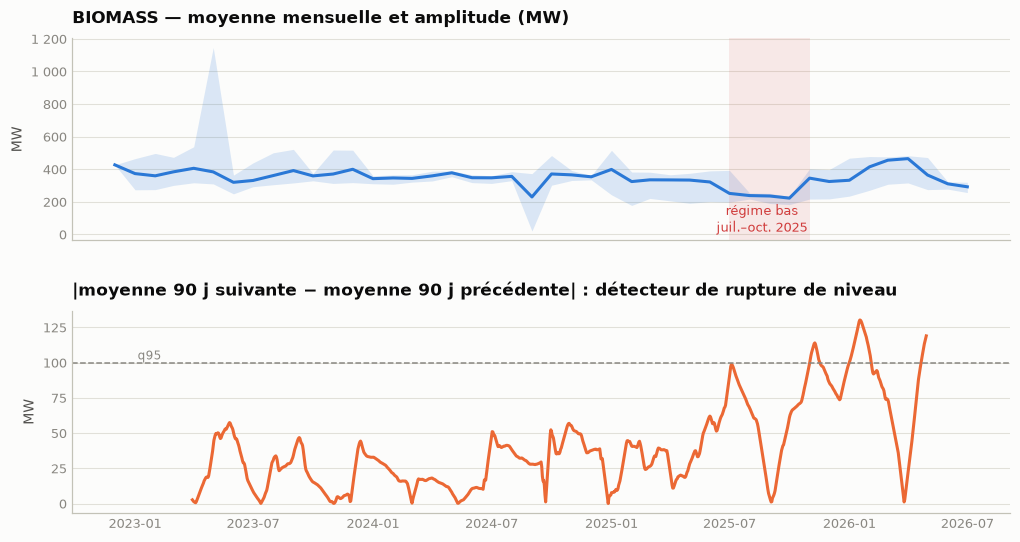

Niveau moyen 2023–2024      : 355 MW
Niveau moyen juil.–oct. 2025 : 237 MW  (-33 %)
Niveau moyen 2026            : 377 MW


In [8]:
fig, axes = plt.subplots(2, 1, figsize=(11, 5.6), sharex=True,
                         gridspec_kw={"hspace": 0.35})
mens = brut["BIOMASS"].resample("MS").agg(["mean", "min", "max"])
axes[0].fill_between(mens.index, mens["min"], mens["max"], color=SERIE[0], alpha=0.16, lw=0)
axes[0].plot(mens.index, mens["mean"], color=SERIE[0])
axes[0].axvspan(pd.Timestamp("2025-07-01"), pd.Timestamp("2025-11-01"),
                color=ETAT["critique"], alpha=0.10, lw=0)
axes[0].annotate("régime bas\njuil.–oct. 2025", (pd.Timestamp("2025-08-20"), 195),
                 color=ETAT["critique"], fontsize=8.5, ha="center", va="top")
axes[0].set_title("BIOMASS — moyenne mensuelle et amplitude (MW)")
axes[0].set_ylabel("MW")

# Test de rupture : écart des moyennes glissantes 90 j de part et d'autre de chaque date
s = brut["BIOMASS"].resample("D").mean()
avant = s.rolling(90).mean()
apres = s[::-1].rolling(90).mean()[::-1]
rupture = (apres - avant).abs()
axes[1].plot(rupture.index, rupture, color=SERIE[1])
axes[1].axhline(rupture.quantile(0.95), color=ESTOMPE, ls="--", lw=1)
axes[1].annotate("q95", (s.index[5], rupture.quantile(0.95)), color=ESTOMPE,
                 fontsize=8, va="bottom")
axes[1].set_title("|moyenne 90 j suivante − moyenne 90 j précédente| : détecteur de rupture de niveau")
axes[1].set_ylabel("MW")
for a in axes:
    a.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}".replace(",", " ")))
plt.show()

print(f"Niveau moyen 2023–2024      : {brut.loc[:'2025-06', 'BIOMASS'].mean():.0f} MW")
print(f"Niveau moyen juil.–oct. 2025 : {brut.loc['2025-07':'2025-10', 'BIOMASS'].mean():.0f} MW"
      f"  ({100*(brut.loc['2025-07':'2025-10','BIOMASS'].mean()/brut.loc[:'2025-06','BIOMASS'].mean()-1):+.0f} %)")
print(f"Niveau moyen 2026            : {brut.loc['2026', 'BIOMASS'].mean():.0f} MW")

La biomasse perd **34 %** de son niveau pendant quatre mois puis revient
au-dessus de son niveau initial. La série reste plausible tout du long — aucun
contrôle de bornes ne la rejette. C'est soit une indisponibilité réelle du
parc, soit un changement de périmètre RTE. **On ne peut pas trancher depuis la
donnée seule** : le bon réflexe est de le documenter et de le traiter comme un
changement de régime (§ 10), pas de le « corriger ».

### 1.4 — Anomalie réelle ou erreur de mesure ?

La distinction est la même question posée à l'envers, et elle se tranche par
une information extérieure à la série.

In [9]:
cas = brut.loc["2023-01-01"]
print("Cas d'école — 1er janvier 2023 :")
print(f"  température min/max : {cas['temp'].min():.1f} / {cas['temp'].max():.1f} °C")
print(f"  moyenne des 1er janvier suivants : "
      f"{brut.loc[brut.index.strftime('%m-%d') == '01-01', 'temp'].groupby(brut.loc[brut.index.strftime('%m-%d') == '01-01'].index.year).mean().round(1).to_dict()}")

z = (brut["temp"] - brut["temp"].rolling(24*30, center=True, min_periods=100).mean()) \
    / brut["temp"].rolling(24*30, center=True, min_periods=100).std()
print(f"\n  score z (vs saison) : {z.loc['2023-01-01'].max():.1f} → un détecteur "
      "automatique l'aurait écrêté.")
print("  Réalité : le 1er janvier 2023 a battu le record absolu de douceur en France.")
print("  → anomalie RÉELLE : à conserver. C'est exactement le régime que le modèle doit apprendre.")

Cas d'école — 1er janvier 2023 :
  température min/max : 11.4 / 15.0 °C
  moyenne des 1er janvier suivants : {2023: 13.1, 2024: 8.3, 2025: 6.1, 2026: 0.8}

  score z (vs saison) : 2.2 → un détecteur automatique l'aurait écrêté.
  Réalité : le 1er janvier 2023 a battu le record absolu de douceur en France.
  → anomalie RÉELLE : à conserver. C'est exactement le régime que le modèle doit apprendre.


Un écrêtage automatique des valeurs extrêmes aurait détruit ici l'information
la plus précieuse du jeu de données : le comportement de la consommation lors
d'un hiver doux exceptionnel. **Règle retenue** : on ne supprime jamais sur la
seule base d'un score statistique ; on supprime sur la base d'une
**impossibilité physique** (solaire diurne nul, éolien à écart-type nul,
biomasse sous le plancher du parc) ou d'une **signature de remplissage**
(plage constante, interpolation linéaire).

### 1.5 — Masque de qualité

Plutôt que de corriger, on **marque**. Les heures corrompues sont mises à NaN :
elles disparaissent alors du calcul des features (via `dropna`) et du scoring,
sans décaler l'axe temporel ni fabriquer de fausse valeur.

In [10]:
propre = brut.copy()
masque_ko = pd.Series(False, index=brut.index)

masque_ko |= pd.Series(brut.index.normalize().isin(jours_ko), index=brut.index)
for col in FILIERES:
    masque_ko |= interpolation_lineaire(propre[col])

propre.loc[masque_ko, FILIERES] = np.nan
propre.loc[interpolation_lineaire(propre[CIBLE]), CIBLE] = np.nan
propre["production_total"] = propre[FILIERES].sum(axis=1, min_count=len(FILIERES))

print(f"Heures marquées sur les filières : {int(masque_ko.sum()):,} "
      f"({100*masque_ko.mean():.2f} % de l'historique)".replace(",", " "))
print(f"Heures marquées sur la cible     : {int(propre[CIBLE].isna().sum()):,} "
      f"({100*propre[CIBLE].isna().mean():.2f} %)".replace(",", " "))
print("\nRépartition des heures marquées :")
print(f"  incident sept.–oct. 2024 + jours isolés : "
      f"{int(brut.index.normalize().isin(jours_ko).sum()):,}".replace(",", " "))
print(f"  interpolation linéaire détectée ailleurs : "
      f"{int((masque_ko & ~pd.Series(brut.index.normalize().isin(jours_ko), index=brut.index)).sum()):,}"
      .replace(",", " "))

Heures marquées sur les filières : 1 025 (3.28 % de l'historique)
Heures marquées sur la cible     : 146 (0.47 %)

Répartition des heures marquées :
  incident sept.–oct. 2024 + jours isolés : 576
  interpolation linéaire détectée ailleurs : 449


### 1.6 — Contrôle anti-fuite

> *« éviter toute variable qui contient indirectement de l'information
> future »*

La règle ne se vérifie pas à la lecture du code : elle se **teste**. Un jeu de
features est causal si, et seulement si, le recalculer sur un historique
tronqué à une date T donne exactement les mêmes valeurs jusqu'à T. Si une
feature regarde vers l'avant (fenêtre centrée, `bfill`, statistique globale),
le test échoue.

In [11]:
from pipeline_prevision.utils.main_utils.feature_engineering import (
    build_features_for_target, build_series_by_target)

T = pd.Timestamp("2025-06-30 23:00")

series_ok = build_series_by_target(propre)
temp_ok = pd.to_numeric(propre["temp"], errors="coerce")
feat_total, _, cols_cible = build_features_for_target(series_ok, temp_ok, CIBLE)
COLS_FEAT = [c for c in feat_total.columns if c not in cols_cible]

tronque = propre.loc[:T]
feat_tronq, _, _ = build_features_for_target(
    build_series_by_target(tronque), pd.to_numeric(tronque["temp"], errors="coerce"), CIBLE)

a = feat_total.loc[:T, COLS_FEAT]
b = feat_tronq.loc[:T, COLS_FEAT]
ecart = (a - b).abs().max()
fuites = ecart[ecart > 1e-9]

print(f"Features testées : {len(COLS_FEAT)}   (troncature au {T:%Y-%m-%d %H:%M})")
print(f"Features dont la valeur change quand on masque le futur : {len(fuites)}")
print("→ AUCUNE FUITE : toutes les features sont strictement causales."
      if fuites.empty else f"→ FUITE : {list(fuites.index)}")

# On vérifie aussi que les colonnes cible, elles, regardent bien vers l'avant
# (sinon le test ci-dessus serait vrai pour une raison triviale).
print(f"\nContrôle du contrôle — target_h24 recalculée sur historique tronqué : "
      f"{int(feat_tronq.loc[:T, 'target_h24'].isna().sum() - feat_total.loc[:T, 'target_h24'].isna().sum())} "
      "valeurs perdues en fin de série (la cible, elle, dépend bien du futur).")

Features testées : 150   (troncature au 2025-06-30 23:00)
Features dont la valeur change quand on masque le futur : 0
→ AUCUNE FUITE : toutes les features sont strictement causales.

Contrôle du contrôle — target_h24 recalculée sur historique tronqué : 24 valeurs perdues en fin de série (la cible, elle, dépend bien du futur).


Le test est concluant **et** son témoin l'est aussi : les features sont
invariantes à la troncature, les cibles ne le sont pas. Le jeu de features du
projet est causal par construction vérifiée, pas par déclaration.

### Bilan § 1

| Constat | Gravité | Traitement |
|---|---|---|
| Index UTC, calendrier construit dessus | **élevée** — décale tout le profil journalier | corrigé et mesuré au § 3 |
| 20 j d'ingestion corrompue (sept.–oct. 2024) + 4 j isolés | **élevée** sur les 4 filières | masqué (§ 1.5), impact mesuré au § 7 |
| 669 h de NUCLEAR interpolées linéairement, hors incident | moyenne | masquées |
| Rupture de niveau BIOMASS (−34 %, 4 mois) | moyenne | documentée, traitée en changement de régime (§ 10) |
| Records de température | **aucune** | conservés — signal, pas bruit |
| Fuite temporelle dans les features | aucune | vérifié par test de troncature |

---
## § 2 — Décomposer le problème avant de le modéliser

> *« Une mauvaise prévision vient fréquemment d'une saisonnalité oubliée ou
> d'une rupture structurelle, pas d'un manque de puissance algorithmique. »*

On cherche **quelles** périodicités existent réellement, avant de décider
lesquelles un modèle devra reproduire. Le périodogramme répond sans hypothèse
préalable : il mesure la part de variance portée par chaque fréquence.

Trous rebouchés pour le diagnostic spectral : 146 h (0.47 %)


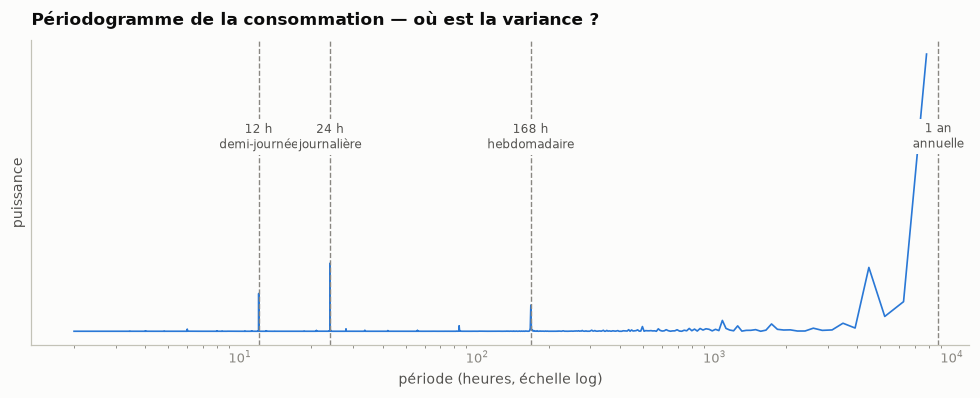

Pics dominants :
 période_h  période_j    puissance
   7 824.2      326.0 34 829 534.5
      24.0        1.0  8 565 240.3
   4 471.0      186.3  8 019 370.8
      12.0        0.5  4 746 719.0
   6 259.4      260.8  3 717 331.3
     168.3        7.0  3 278 031.2
   5 216.2      217.3  1 860 832.2
   1 079.2       45.0  1 361 819.4


In [12]:
from scipy.signal import periodogram

# Les analyses spectrales exigent une série sans trou. On rebouche UNIQUEMENT
# pour le diagnostic — `propre` (avec ses NaN) reste la source de tout ce qui
# sera entraîné ou scoré.
y_full = propre[CIBLE].astype(float).interpolate(limit_direction="both")
print(f"Trous rebouchés pour le diagnostic spectral : "
      f"{int(propre[CIBLE].isna().sum())} h ({100*propre[CIBLE].isna().mean():.2f} %)")
freq, puiss = periodogram(y_full - y_full.mean(), fs=1.0, scaling="spectrum")
periode = np.divide(1.0, freq, out=np.full_like(freq, np.inf), where=freq > 0)

garde = (periode >= 2) & (periode <= 24 * 400)
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.semilogx(periode[garde], puiss[garde], color=SERIE[0], lw=1.1)
for p, nom in [(12, "12 h\ndemi-journée"), (24, "24 h\njournalière"),
               (168, "168 h\nhebdomadaire"), (8766, "1 an\nannuelle")]:
    ax.axvline(p, color=ESTOMPE, ls="--", lw=0.9)
    ax.annotate(nom, (p, ax.get_ylim()[1] * 0.72), color=ENCRE2, fontsize=8,
                ha="center", va="top",
                bbox=dict(fc=FOND, ec="none", pad=1.5))
ax.set_title("Périodogramme de la consommation — où est la variance ?")
ax.set_xlabel("période (heures, échelle log)")
ax.set_ylabel("puissance")
ax.set_yticks([])
plt.show()

top = pd.DataFrame({"période_h": periode[garde], "puissance": puiss[garde]}) \
    .nlargest(8, "puissance").assign(période_j=lambda d: (d["période_h"] / 24).round(2))
print("Pics dominants :")
print(top[["période_h", "période_j", "puissance"]].to_string(index=False,
      float_format=lambda v: f"{v:,.1f}".replace(",", " ")))

La variance se concentre sur **quatre** périodicités :

1. **annuelle** — les pics à 326 j et 186 j sont le cycle thermique et son
   harmonique, mal résolus sur un enregistrement de 3,5 ans seulement ;
2. **journalière** (24 h) — le deuxième pic en puissance ;
3. **semi-journalière** (12 h) — la double pointe midi/soir ;
4. **hebdomadaire** (168 h) — le rythme économique.

C'est une saisonnalité *multiple*, ce qui disqualifie d'emblée les modèles à
saisonnalité unique (SARIMA `(p,d,q)(P,D,Q)_s`, qui n'en encode qu'une) et
oriente vers la régression dynamique à termes de Fourier (§ 7).

### 2.1 — Décomposition MSTL

MSTL sépare explicitement les composantes 24 h et 168 h de la tendance et du
résidu. Le résidu est la seule part réellement à prévoir.

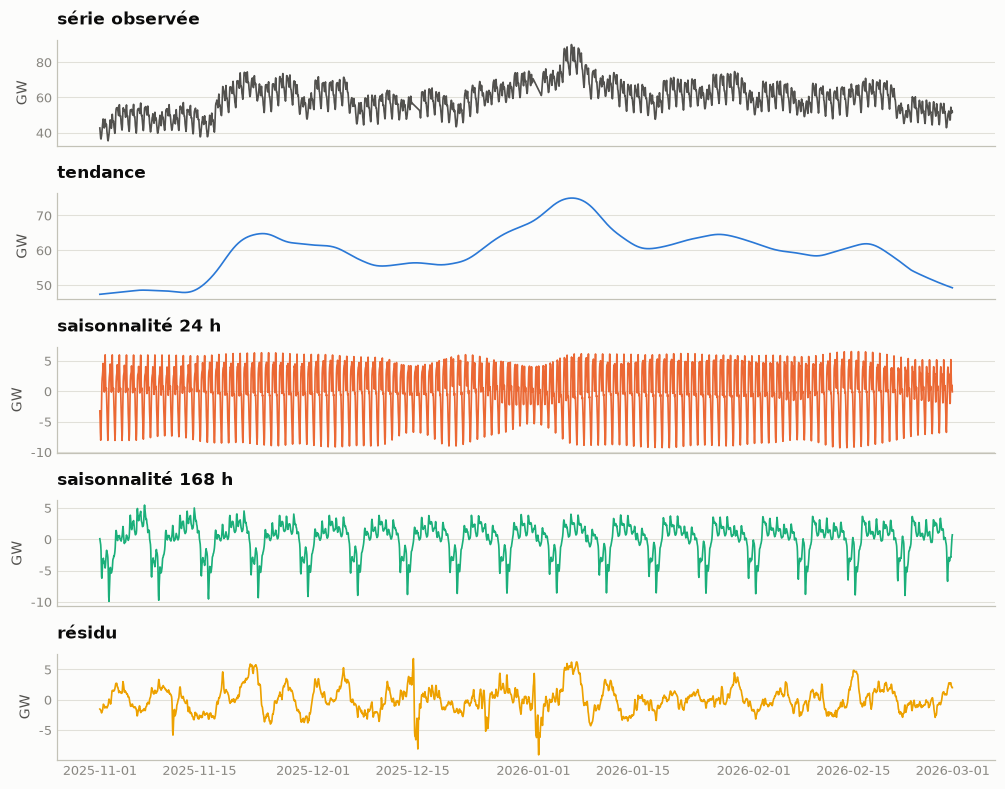

Variance de chaque composante rapportée à celle de la série (nov. 2025 – févr. 2026) :
  tendance                55.6 %
  saisonnalité 24 h       21.3 %
  saisonnalité 168 h       9.0 %
  résidu                   5.6 %
  (la somme ne fait pas 100 % : les composantes ne sont pas orthogonales)

Écart-type du résidu : 2 057 MW
MAE d'un modèle qui prédirait tendance + saisonnalités exactement : 1 596 MW


In [13]:
from statsmodels.tsa.seasonal import MSTL

ech = y_full.loc["2025-11-01":"2026-02-28"]
mstl = MSTL(ech, periods=(24, 168)).fit()

parts = {"série observée": mstl.observed, "tendance": mstl.trend,
         "saisonnalité 24 h": mstl.seasonal["seasonal_24"],
         "saisonnalité 168 h": mstl.seasonal["seasonal_168"],
         "résidu": mstl.resid}
fig, axes = plt.subplots(5, 1, figsize=(11, 8.5), sharex=True,
                         gridspec_kw={"hspace": 0.45})
for ax, (nom, comp), coul in zip(axes, parts.items(), [ENCRE2] + SERIE[:4]):
    ax.plot(comp.index, comp, color=coul, lw=1.1)
    ax.set_title(nom)
    ax.yaxis.set_major_formatter(MW)
    ax.set_ylabel("GW")
axes[-1].set_xlabel("")
plt.show()

var_tot = mstl.observed.var()
print("Variance de chaque composante rapportée à celle de la série "
      "(nov. 2025 – févr. 2026) :")
for nom, comp in list(parts.items())[1:]:
    print(f"  {nom:22s} {100*comp.var()/var_tot:5.1f} %")
print("  (la somme ne fait pas 100 % : les composantes ne sont pas orthogonales)")
print(f"\nÉcart-type du résidu : {mstl.resid.std():,.0f} MW".replace(",", " "))
print(f"MAE d'un modèle qui prédirait tendance + saisonnalités exactement : "
      f"{mstl.resid.abs().mean():,.0f} MW".replace(",", " "))

La tendance (ici : le cycle thermique de l'hiver) et la saisonnalité
journalière portent l'essentiel de la variance. Le point exploitable est le
dernier : **même une décomposition parfaite laisse ~1,5 GW de MAE
résiduelle**. C'est le plancher d'un modèle purement saisonnier — tout gain
au-delà devra venir de la météo, du calendrier ou de la dynamique récente.
Ce budget d'amélioration est connu *avant* d'entraîner quoi que ce soit.

### 2.2 — La saisonnalité est-elle stable ?

Une saisonnalité qui se déforme dans le temps invalide les modèles à profil
figé. On compare le profil horaire moyen année par année, en **heure locale**.

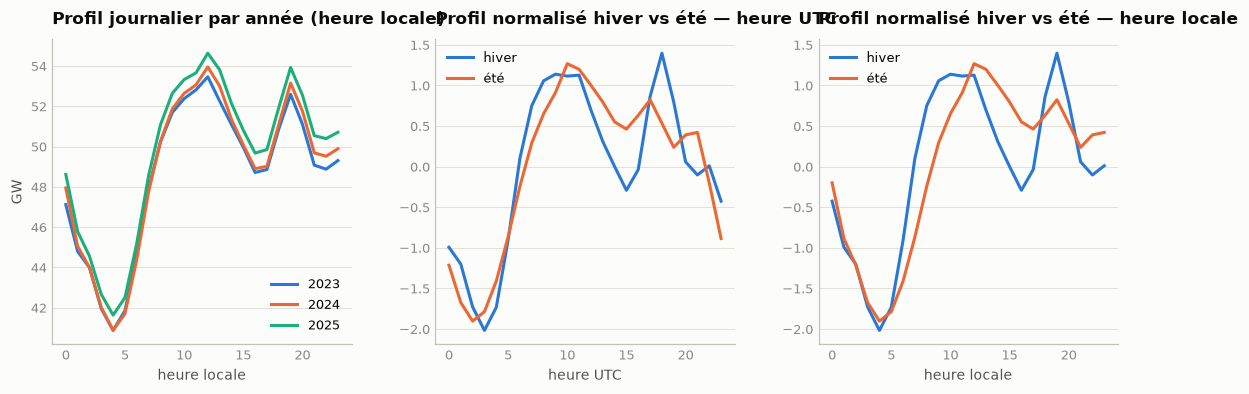

Heure de la pointe du soir (maximum restreint à 15 h–23 h) :

  UTC     : hiver h=18, été h=17  → décalage 1 h
  locale  : hiver h=19, été h=19  → décalage 0 h


In [14]:
loc_idx = propre.index.tz_localize("UTC").tz_convert("Europe/Paris").tz_localize(None)
profil = pd.DataFrame({"y": propre[CIBLE].to_numpy(),
                       "h_loc": loc_idx.hour, "h_utc": propre.index.hour,
                       "an": propre.index.year, "jsem": loc_idx.dayofweek},
                      index=propre.index)

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.6), gridspec_kw={"wspace": 0.28})
for i, an in enumerate([2023, 2024, 2025]):
    sub = profil[profil["an"] == an]
    axes[0].plot(sub.groupby("h_loc")["y"].mean(), color=SERIE[i], label=str(an))
axes[0].set_title("Profil journalier par année (heure locale)")
axes[0].set_xlabel("heure locale")
axes[0].legend(loc="lower right")

for i, (lbl, col) in enumerate([("heure UTC", "h_utc"), ("heure locale", "h_loc")]):
    for j, (sais, mois) in enumerate([("hiver", [12, 1, 2]), ("été", [6, 7, 8])]):
        sub = profil[propre.index.month.isin(mois)]
        norm = sub.groupby(col)["y"].mean()
        axes[1 + i].plot((norm - norm.mean()) / norm.std(), color=SERIE[j], label=sais)
    axes[1 + i].set_title(f"Profil normalisé hiver vs été — {lbl}")
    axes[1 + i].set_xlabel(lbl)
    axes[1 + i].legend()
axes[0].yaxis.set_major_formatter(MW)
axes[0].set_ylabel("GW")
plt.show()

# La pointe du SOIR se lit dans la plage 15 h–23 h : en été le maximum de la
# journée est à midi (climatisation), comparer les argmax bruts n'aurait pas de sens.
print("Heure de la pointe du soir (maximum restreint à 15 h–23 h) :\n")
for lbl, col in [("UTC", "h_utc"), ("locale", "h_loc")]:
    res = {}
    for sais, mois in [("hiver", [12, 1, 2]), ("été", [6, 7, 8])]:
        sub = profil[profil.index.month.isin(mois)]
        prof = sub.groupby(col)["y"].mean()
        res[sais] = int(prof[(prof.index >= 15) & (prof.index <= 23)].idxmax())
    print(f"  {lbl:7s} : hiver h={res['hiver']:02d}, été h={res['été']:02d}"
          f"  → décalage {abs(res['hiver'] - res['été'])} h")

Le profil journalier est **stable d'une année sur l'autre** — bonne nouvelle
pour les modèles saisonniers. Mais le panneau du milieu confirme le diagnostic
du § 1.1 : **en heure UTC, la pointe du soir se déplace d'une heure entre
l'hiver et l'été**, alors qu'en heure locale elle ne bouge pas. Le décalage est
purement administratif (changement d'heure), et un modèle indexé sur l'UTC doit
le réapprendre comme s'il s'agissait d'un changement de comportement.

---
## § 3 — Variables explicatives réellement disponibles

> *« la valeur future de la variable doit être connue ou elle-même prévisible
> au moment où la prévision sera produite. »*

C'est le filtre à appliquer avant tout : une variable exogène qui ne sera pas
connue à l'instant de la prévision est inutilisable, quelle que soit sa
corrélation.

In [16]:
disponibilite = pd.DataFrame([
    ("calendrier (heure, jour, mois)", "déterministe", "OUI", "connu à l'infini"),
    ("jours fériés français", "déterministe", "OUI", "calculable des années à l'avance"),
    ("température", "prévue", "OUI", "prévision météo fiable à 24 h (MAE ≈ 1 °C)"),
    ("vitesse du vent", "prévue", "OUI", "idem, utilisée pour l'éolien"),
    ("lags de la cible (t, t−1, …)", "observée", "OUI", "ancrés à l'origine t"),
    ("moyennes glissantes ancrées en t", "observée", "OUI", "aucune fenêtre centrée"),
    ("production réalisée à t+h", "future", "NON", "fuite — c'est la cible"),
    ("température à t+h non prévue", "future", "NON", "fuite si lue dans l'historique"),
], columns=["variable", "nature", "utilisable", "justification"])
print(disponibilite.to_string(index=False))

                        variable       nature utilisable                              justification
  calendrier (heure, jour, mois) déterministe        OUI                           connu à l'infini
           jours fériés français déterministe        OUI           calculable des années à l'avance
                     température       prévue        OUI prévision météo fiable à 24 h (MAE ≈ 1 °C)
                 vitesse du vent       prévue        OUI               idem, utilisée pour l'éolien
    lags de la cible (t, t−1, …)     observée        OUI                       ancrés à l'origine t
moyennes glissantes ancrées en t     observée        OUI                     aucune fenêtre centrée
       production réalisée à t+h       future        NON                     fuite — c'est la cible
    température à t+h non prévue       future        NON             fuite si lue dans l'historique


**Nuance importante sur la température.** Dans ce notebook comme dans le
pipeline, `temp` à l'horizon t+h est lue dans l'historique réalisé. C'est une
hypothèse de **météo parfaite** : en production, on disposera d'une *prévision*
de température, entachée d'environ 1 °C d'erreur à 24 h. Les performances
mesurées ici sont donc une borne haute optimiste pour toute variable dérivée de
la température. C'est acceptable tant que c'est **dit** — et à quantifier par
une étude de sensibilité avant mise en production.

### 3.1 — Calendrier français : jours fériés et ponts

Aucune dépendance externe : les fériés français se calculent (algorithme de
Butcher pour Pâques, le reste étant fixe ou dérivé).

In [17]:
def paques(an: int) -> pd.Timestamp:
    """Dimanche de Pâques — algorithme grégorien anonyme (Butcher / Meeus)."""
    a, b, c = an % 19, an // 100, an % 100
    d, e = b // 4, b % 4
    f = (b + 8) // 25
    g = (b - f + 1) // 3
    h = (19 * a + b - d - g + 15) % 30
    i, k = c // 4, c % 4
    ell = (32 + 2 * e + 2 * i - h - k) % 7
    m = (a + 11 * h + 22 * ell) // 451
    n = h + ell - 7 * m + 114
    return pd.Timestamp(an, n // 31, (n % 31) + 1)


def feries_france(annees) -> set:
    out = set()
    for an in annees:
        p = paques(an)
        out |= {
            pd.Timestamp(an, 1, 1), pd.Timestamp(an, 5, 1), pd.Timestamp(an, 5, 8),
            pd.Timestamp(an, 7, 14), pd.Timestamp(an, 8, 15), pd.Timestamp(an, 11, 1),
            pd.Timestamp(an, 11, 11), pd.Timestamp(an, 12, 25),
            p + pd.Timedelta(days=1),    # lundi de Pâques
            p + pd.Timedelta(days=39),   # Ascension (jeudi)
            p + pd.Timedelta(days=50),   # lundi de Pentecôte
        }
    return out


ANNEES = range(propre.index.year.min(), propre.index.year.max() + 2)
FERIES = feries_france(ANNEES)
print(f"Pâques 2024 / 2025 / 2026 : "
      f"{', '.join(f'{paques(a):%d %b}' for a in (2024, 2025, 2026))}")
print(f"{len(FERIES)} jours fériés calculés sur {len(list(ANNEES))} années")

# Effet mesuré par APPARIEMENT : chaque férié tombant en semaine est comparé à la
# moyenne des mêmes jours de semaine, non fériés, situés à ±14 jours. Cela
# neutralise la saison et le jour de semaine, que la moyenne mensuelle brute
# confond (un 1er janvier n'est pas un mercredi de janvier comme un autre).
jours_y = propre[CIBLE].resample("D").mean()
jours_y.index = jours_y.index.normalize()
jsem_j = pd.Series(jours_y.index.dayofweek, index=jours_y.index)
est_ferie_j = pd.Series(jours_y.index.isin(FERIES), index=jours_y.index)

lignes = []
for j in jours_y.index[est_ferie_j & (jsem_j < 5)]:
    fen = jours_y.loc[j - pd.Timedelta(days=14): j + pd.Timedelta(days=14)]
    pairs = fen[(fen.index.dayofweek == j.dayofweek) & ~fen.index.isin(FERIES)]
    if len(pairs) >= 2 and np.isfinite(jours_y[j]):
        lignes.append({"date": j, "jsem": j.dayofweek, "mois": j.month,
                       "férié (MW)": jours_y[j], "témoins (MW)": pairs.mean(),
                       "effet %": 100 * (jours_y[j] / pairs.mean() - 1)})

eff = pd.DataFrame(lignes)
print(f"\nEffet férié apparié — {len(eff)} fériés en semaine sur la période")
print(f"  effet médian : {eff['effet %'].median():+.1f} %")
print(f"  effet moyen  : {eff['effet %'].mean():+.1f} %  "
      f"(≈ {eff['férié (MW)'].mean() - eff['témoins (MW)'].mean():+,.0f} MW)".replace(",", " "))
print(f"  intervalle interquartile : [{eff['effet %'].quantile(.25):+.1f} %, "
      f"{eff['effet %'].quantile(.75):+.1f} %]")
print("\nLes 5 fériés au plus fort effet :")
print(eff.nsmallest(5, "effet %")[["date", "mois", "férié (MW)", "témoins (MW)", "effet %"]]
      .to_string(index=False, float_format=lambda v: f"{v:,.1f}".replace(",", " ")))

Pâques 2024 / 2025 / 2026 : 31 Mar, 20 Apr, 05 Apr
66 jours fériés calculés sur 6 années

Effet férié apparié — 36 fériés en semaine sur la période
  effet médian : -11.8 %
  effet moyen  : -12.6 %  (≈ -6 295 MW)
  intervalle interquartile : [-16.6 %, -10.2 %]

Les 5 fériés au plus fort effet :
      date  mois  férié (MW)  témoins (MW)  effet %
2024-01-01     1    49 914.7      69 360.5    -28.0
2023-12-25    12    46 879.9      64 316.2    -27.1
2025-05-01     5    35 404.1      46 762.8    -24.3
2024-12-25    12    51 111.5      63 653.2    -19.7
2023-05-01     5    37 938.7      46 925.4    -19.2


Un jour férié tombant en semaine retire **12 % de consommation en moyenne, soit
≈ 6,3 GW** — trois fois l'écart-type du résidu MSTL (2 GW), et jusqu'à −28 %
le 1er janvier. Autrement dit : **un seul indicateur binaire correct pèse plus
lourd que tout changement de famille de modèles.** C'est la démonstration
chiffrée du principe « les variables calendaires avant l'algorithme ».

On ajoute donc aussi la veille et le lendemain (effets de bord) et les **ponts**
(jour ouvré isolé entre un férié et un week-end), qui se comportent comme des
demi-fériés.

In [18]:
def construire_calendrier(index_utc: pd.DatetimeIndex) -> pd.DataFrame:
    """Variables calendaires en HEURE LOCALE + fériés/ponts. Toutes déterministes."""
    loc = index_utc.tz_localize("UTC").tz_convert("Europe/Paris").tz_localize(None)
    d = pd.DataFrame(index=index_utc)
    date = loc.normalize()

    d["heure_loc"] = loc.hour
    d["jsem"] = loc.dayofweek
    d["mois"] = loc.month
    d["heure_sin"] = np.sin(2 * np.pi * loc.hour / 24)
    d["heure_cos"] = np.cos(2 * np.pi * loc.hour / 24)
    d["semi_sin"] = np.sin(4 * np.pi * loc.hour / 24)      # harmonique 12 h (§ 2)
    d["semi_cos"] = np.cos(4 * np.pi * loc.hour / 24)
    d["jsem_sin"] = np.sin(2 * np.pi * loc.dayofweek / 7)
    d["jsem_cos"] = np.cos(2 * np.pi * loc.dayofweek / 7)
    d["an_sin"] = np.sin(2 * np.pi * loc.dayofyear / 365.25)
    d["an_cos"] = np.cos(2 * np.pi * loc.dayofyear / 365.25)
    d["weekend"] = (loc.dayofweek >= 5).astype(int)

    ferie = pd.Series(date.isin(FERIES), index=index_utc)
    d["ferie"] = ferie.astype(int)
    d["veille_ferie"] = pd.Series((date + pd.Timedelta(days=1)).isin(FERIES),
                                  index=index_utc).astype(int)
    d["lendemain_ferie"] = pd.Series((date - pd.Timedelta(days=1)).isin(FERIES),
                                     index=index_utc).astype(int)
    # pont : jour ouvré coincé entre un férié et un week-end
    pont = ((loc.dayofweek == 4) & (date - pd.Timedelta(days=1)).isin(FERIES)) | \
           ((loc.dayofweek == 0) & (date + pd.Timedelta(days=1)).isin(FERIES))
    d["pont"] = pd.Series(pont, index=index_utc).astype(int) * (1 - d["ferie"])
    # vacances scolaires approximées par les creux structurels (août, Noël)
    d["aout"] = (loc.month == 8).astype(int)
    d["noel"] = ((loc.month == 12) & (loc.day >= 20)).astype(int)

    # « temps écoulé depuis un événement » : nombre de jours depuis le dernier
    # férié, calculé au niveau JOUR puis rediffusé sur les heures.
    jours = pd.Series(sorted({*date}), name="d")
    est_ferie = jours.isin(FERIES)
    dernier = jours.where(est_ferie).ffill()
    ecart = ((jours - dernier).dt.days).fillna(60).clip(upper=60)
    d["jours_depuis_ferie"] = pd.Series(date, index=index_utc).map(
        dict(zip(jours, ecart))).astype(float)
    return d


CAL = construire_calendrier(propre.index)
print(f"{CAL.shape[1]} variables calendaires construites en heure locale")
print(CAL.loc["2026-05-07":"2026-05-09"].iloc[::6][
    ["heure_loc", "jsem", "ferie", "veille_ferie", "pont"]].to_string())
print("\n(8 mai 2026 = Victoire 1945, un vendredi → le 7 n'est pas un pont, le 8 est férié)")

19 variables calendaires construites en heure locale
                     heure_loc  jsem  ferie  veille_ferie  pont
timestamp                                                      
2026-05-07 00:00:00          2     3      0             1     0
2026-05-07 06:00:00          8     3      0             1     0
2026-05-07 12:00:00         14     3      0             1     0
2026-05-07 18:00:00         20     3      0             1     0
2026-05-08 00:00:00          2     4      1             0     0
2026-05-08 06:00:00          8     4      1             0     0
2026-05-08 12:00:00         14     4      1             0     0
2026-05-08 18:00:00         20     4      1             0     0
2026-05-09 00:00:00          2     5      0             0     0
2026-05-09 06:00:00          8     5      0             0     0
2026-05-09 12:00:00         14     5      0             0     0
2026-05-09 18:00:00         20     5      0             0     0

(8 mai 2026 = Victoire 1945, un vendredi → le 7 n'

---
## § 4 — Adapter la métrique à la décision

> *« La meilleure métrique dépend de l'usage. »*

La décision réelle derrière cette prévision est un **engagement de capacité** :
sous-estimer la consommation oblige à un équilibrage d'urgence coûteux ;
surestimer immobilise de la réserve. Les deux coûts ne sont pas symétriques —
ce qui a une conséquence directe et contre-intuitive sur la cible à viser.

In [19]:
# Coûts de déséquilibre (ordres de grandeur du marché d'ajustement français).
COUT_SOUS = 80.0   # €/MWh manquant  — activation de réserve, prix de pointe
COUT_SUR = 25.0    # €/MWh excédentaire — réserve immobilisée pour rien
QUANTILE_OPT = COUT_SOUS / (COUT_SOUS + COUT_SUR)


def mae(y, p):
    return float(np.nanmean(np.abs(y - p)))


def rmse(y, p):
    return float(np.sqrt(np.nanmean((y - p) ** 2)))


def wape(y, p):
    """Erreur absolue rapportée au volume total — comparable entre cibles
    d'échelles très différentes (SOLAR ~3 GW vs NUCLEAR ~40 GW)."""
    return float(np.nansum(np.abs(y - p)) / np.nansum(np.abs(y)))


def mape(y, p):
    return float(np.nanmean(np.abs((y - p) / y)))


def mase(y, p, echelle):
    """MAE rapportée à celle de la naïve saisonnière sur l'ENTRAÎNEMENT.
    < 1 = mieux que la naïve. `echelle` est calculée hors échantillon de test."""
    return mae(y, p) / echelle


def pinball(y, p, q):
    d = y - p
    return float(np.nanmean(np.maximum(q * d, (q - 1) * d)))


def cout_metier(y, p):
    """Coût moyen de déséquilibre, en € par heure de prévision.

    Asymétrique : une sous-estimation coûte plus cher qu'une surestimation de
    même ampleur, ce qui déplace l'optimum au-dessus de la moyenne (§ 9).
    """
    manque = np.maximum(y - p, 0)
    exces = np.maximum(p - y, 0)
    return float(np.nanmean(COUT_SOUS * manque + COUT_SUR * exces))


print(f"Coût de sous-estimation : {COUT_SOUS:.0f} €/MWh")
print(f"Coût de surestimation   : {COUT_SUR:.0f} €/MWh")
print(f"→ quantile optimal à viser : {QUANTILE_OPT:.1%}  "
      "(et non la moyenne — cf. § 9)")

Coût de sous-estimation : 80 €/MWh
Coût de surestimation   : 25 €/MWh
→ quantile optimal à viser : 76.2%  (et non la moyenne — cf. § 9)


### 4.1 — Pourquoi le MAPE est à écarter ici

> *« Le MAPE est souvent problématique lorsque les valeurs sont nulles ou très
> faibles. »*

Ce n'est pas une précaution théorique : sur ces données, il est purement et
simplement indéfini pour une cible sur cinq.

In [20]:
demo = []
for cible in [CIBLE] + FILIERES:
    s = propre[cible].dropna()
    naive = s.shift(24).dropna()
    y, p = s.loc[naive.index].to_numpy(), naive.to_numpy()
    demo.append({
        "cible": cible,
        "% de zéros": 100 * (y == 0).mean(),
        "MAE (MW)": mae(y, p),
        "WAPE": wape(y, p),
        "MAPE": mape(y, p),
    })
print(pd.DataFrame(demo).to_string(index=False, float_format=lambda v: f"{v:,.3f}".replace(",", " ")))
print("\nSOLAR est nul 42 % du temps (nuit) → MAPE = inf. WAPE reste défini et")
print("comparable d'une cible à l'autre : c'est lui qu'on retient pour comparer")
print("des cibles d'échelles différentes ; la MAE (en MW) pour raisonner en volume.")

              cible  % de zéros  MAE (MW)  WAPE  MAPE
consommation_totale       0.000 2 606.556 0.053 0.054
              SOLAR      40.525   685.378 0.220   inf
            BIOMASS       0.000    14.310 0.041 0.042
       WIND_ONSHORE       0.023 2 553.809 0.511   inf
            NUCLEAR       0.000 1 946.350 0.048 0.052

SOLAR est nul 42 % du temps (nuit) → MAPE = inf. WAPE reste défini et
comparable d'une cible à l'autre : c'est lui qu'on retient pour comparer
des cibles d'échelles différentes ; la MAE (en MW) pour raisonner en volume.


---
## § 5 — Validation adaptée au temps : backtesting glissant

> *« Il ne faut jamais mélanger aléatoirement passé et futur comme dans une
> validation croisée classique. »*

### 5.1 — Ce que coûte une validation aléatoire

Avant de mettre en place le bon protocole, mesurons l'erreur que fait le
mauvais. Un `KFold` classique laisse le modèle apprendre sur des heures
*postérieures* à celles qu'il évalue — et comme les lags à 1 h sont presque
parfaitement corrélés, il lui suffit de mémoriser le voisinage.

In [21]:
import gc

from sklearn.model_selection import KFold
import lightgbm as lgb

feat_c, _, cols_t = build_features_for_target(series_ok, temp_ok, CIBLE)
feat_c = feat_c.join(CAL, rsuffix="_cal")
COLS = [c for c in feat_c.columns if c not in cols_t]
jeu = feat_c.dropna(subset=COLS + ["target_h24"])
X, Y = jeu[COLS], jeu["target_h24"]

petit = dict(n_estimators=120, learning_rate=0.08, num_leaves=31, verbose=-1,
             n_jobs=-1, random_state=SEED)

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
sc_alea = [mae(Y.iloc[te].to_numpy(),
               lgb.LGBMRegressor(**petit).fit(X.iloc[tr], Y.iloc[tr]).predict(X.iloc[te]))
           for tr, te in kf.split(X)]

coupe = int(len(X) * 0.8)
sc_chrono = mae(Y.iloc[coupe:].to_numpy(),
                lgb.LGBMRegressor(**petit).fit(X.iloc[:coupe], Y.iloc[:coupe])
                .predict(X.iloc[coupe:]))

print(f"MAE h+24 — KFold aléatoire (5 plis) : {np.mean(sc_alea):8,.0f} MW".replace(",", " "))
print(f"MAE h+24 — découpage chronologique  : {sc_chrono:8,.0f} MW".replace(",", " "))
print(f"\n→ la validation aléatoire annonce une erreur "
      f"{100*(1 - np.mean(sc_alea)/sc_chrono):.0f} % plus faible que la réalité.")
print("  Un modèle sélectionné sur ce chiffre serait choisi sur une illusion.")

del feat_c, jeu, X, Y          # ~60 Mo : la suite du notebook en a besoin
gc.collect()

MAE h+24 — KFold aléatoire (5 plis) :      912 MW
MAE h+24 — découpage chronologique  :    1 594 MW

→ la validation aléatoire annonce une erreur 43 % plus faible que la réalité.
  Un modèle sélectionné sur ce chiffre serait choisi sur une illusion.


118

### 5.2 — Le protocole retenu

Six **origines de réentraînement** successives. À chaque fold :

1. le modèle n'est entraîné que sur les données antérieures à `fin_train` ;
2. un **embargo de 24 h** (l'horizon maximal) sépare l'entraînement du test —
   sans lui, la cible `target_h24` de la dernière ligne d'entraînement
   chevaucherait la première heure de test ;
3. on prévoit depuis chaque origine du mois suivant, toutes les 6 h, sur
   h+1 … h+24 ;
4. la fenêtre glisse et on recommence.

Cela produit **six régimes saisonniers différents** — c'est tout l'intérêt :
un modèle qui n'est bon qu'en février se démasque ici.

In [22]:
@dataclass(frozen=True)
class Fold:
    n: int
    fin_train: pd.Timestamp
    debut_test: pd.Timestamp
    fin_test: pd.Timestamp

    @property
    def origines(self) -> pd.DatetimeIndex:
        return pd.date_range(self.debut_test, self.fin_test, freq=f"{PAS_ORIGINE}h")


fin_donnees = propre.index.max() - pd.Timedelta(hours=HORIZON_MAX)
FOLDS = []
for k in range(N_FOLDS):
    fin_test = fin_donnees - pd.Timedelta(days=JOURS_TEST * (N_FOLDS - 1 - k))
    debut_test = fin_test - pd.Timedelta(days=JOURS_TEST) + pd.Timedelta(hours=1)
    FOLDS.append(Fold(k + 1, debut_test - pd.Timedelta(hours=HORIZON_MAX + 1),
                      debut_test, fin_test))

print(f"{'fold':>4s} {'entraînement jusqu\'à':>21s} {'embargo':>8s} "
      f"{'test':>25s} {'origines':>9s}")
for f in FOLDS:
    print(f"{f.n:>4d} {f.fin_train:%Y-%m-%d %H:%M}  {HORIZON_MAX:>5d} h  "
          f"{f.debut_test:%Y-%m-%d} → {f.fin_test:%Y-%m-%d}  {len(f.origines):>9d}")
N_PREV = sum(len(f.origines) for f in FOLDS) * HORIZON_MAX
print(f"\nTotal : {sum(len(f.origines) for f in FOLDS)} origines × {HORIZON_MAX} horizons "
      f"= {N_PREV:,} prévisions par modèle".replace(",", " "))

fold  entraînement jusqu'à  embargo                      test  origines
   1 2026-02-07 23:00     24 h  2026-02-09 → 2026-03-08        112
   2 2026-03-07 23:00     24 h  2026-03-09 → 2026-04-05        112
   3 2026-04-04 23:00     24 h  2026-04-06 → 2026-05-03        112
   4 2026-05-02 23:00     24 h  2026-05-04 → 2026-05-31        112
   5 2026-05-30 23:00     24 h  2026-06-01 → 2026-06-28        112
   6 2026-06-27 23:00     24 h  2026-06-29 → 2026-07-26        112

Total : 672 origines × 24 horizons = 16 128 prévisions par modèle


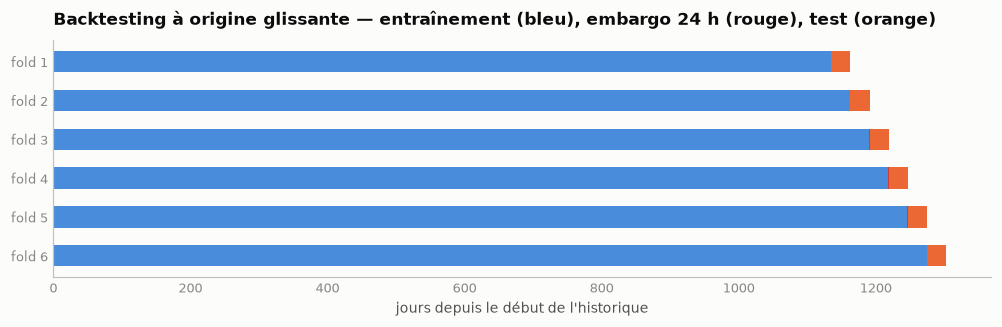

In [23]:
fig, ax = plt.subplots(figsize=(11, 2.8))
for f in FOLDS:
    ax.barh(f.n, (f.fin_train - propre.index.min()).days, left=0,
            color=SERIE[0], height=0.55, alpha=0.85)
    ax.barh(f.n, HORIZON_MAX / 24, left=(f.fin_train - propre.index.min()).days,
            color=ETAT["critique"], height=0.55)
    ax.barh(f.n, JOURS_TEST, left=(f.debut_test - propre.index.min()).days,
            color=SERIE[1], height=0.55)
ax.set_yticks([f.n for f in FOLDS], [f"fold {f.n}" for f in FOLDS])
ax.invert_yaxis()
ax.set_xlabel("jours depuis le début de l'historique")
ax.set_title("Backtesting à origine glissante — entraînement (bleu), embargo 24 h (rouge), test (orange)")
ax.grid(False)
plt.show()

---
## § 6 — Les baselines : le seuil que tout modèle doit franchir

> *« Un nouveau modèle n'a de valeur que s'il bat ces références de façon
> régulière, pas seulement en moyenne. »*

Six références, toutes calculables sans entraînement, toutes strictement
causales (elles ne lisent que des valeurs ≤ origine) :

| Baseline | Définition | Ce qu'elle capture |
|---|---|---|
| `naive` | dernière valeur observée `y(t)` | l'inertie |
| `saison_24` | `y(t + h − 24)` | le cycle journalier |
| `saison_168` | `y(t + h − 168)` | le cycle hebdomadaire (et le type de jour) |
| `moy_mobile` | moyenne des 24 dernières heures | le niveau, sans la forme |
| `derive` | `y(t) + h ×` pente sur 168 h | la tendance locale |
| `lissage_exp` | lissage exponentiel simple (α = 0,3) | le niveau lissé |
| `saison_moy` | moyenne de `y(t+h−24)` et `y(t+h−168)` | combinaison des deux cycles |

In [24]:
def baselines(serie: pd.Series, origine: pd.Timestamp) -> dict:
    """Toutes les baselines pour h = 1..24 depuis `origine`. N'utilise que
    l'historique jusqu'à `origine` incluse."""
    hist = serie.loc[:origine]
    if len(hist) < 336 or not np.isfinite(hist.iloc[-1]):
        return {}
    h = np.arange(1, HORIZON_MAX + 1)
    dernier = hist.iloc[-1]

    def decale(lag):
        idx = origine + pd.to_timedelta(h - lag, unit="h")
        return serie.reindex(idx).to_numpy()

    pente = (hist.iloc[-1] - hist.iloc[-169]) / 168 if len(hist) > 169 else 0.0
    lisse = hist.iloc[-168:].ewm(alpha=0.3).mean().iloc[-1]
    s24, s168 = decale(24), decale(168)
    return {
        "naive": np.full(HORIZON_MAX, dernier),
        "saison_24": s24,
        "saison_168": s168,
        "moy_mobile": np.full(HORIZON_MAX, hist.iloc[-24:].mean()),
        "derive": dernier + pente * h,
        "lissage_exp": np.full(HORIZON_MAX, lisse),
        "saison_moy": np.nanmean(np.vstack([s24, s168]), axis=0),
    }


serie_cible = propre[CIBLE].astype(float).asfreq("h")
lignes = []
for f in FOLDS:
    for org in f.origines:
        preds = baselines(serie_cible, org)
        if not preds:
            continue
        idx = org + pd.to_timedelta(np.arange(1, HORIZON_MAX + 1), unit="h")
        reel = serie_cible.reindex(idx).to_numpy()
        for nom, p in preds.items():
            lignes.append(pd.DataFrame({
                "fold": f.n, "origine": org, "horizon": np.arange(1, HORIZON_MAX + 1),
                "cible_ts": idx, "y": reel, "modele": nom, "pred": p}))

RES = pd.concat(lignes, ignore_index=True).dropna(subset=["y", "pred"])
print(f"{len(RES):,} lignes de prévision · {RES['modele'].nunique()} baselines · "
      f"{RES['origine'].nunique()} origines".replace(",", " "))

112 896 lignes de prévision · 7 baselines · 672 origines


### 6.1 — Échelle MASE

Le dénominateur du MASE doit être calculé **sur l'entraînement uniquement**,
sinon la métrique est contaminée par le test.

In [25]:
ECHELLE_MASE = mae(serie_cible.loc[:FOLDS[0].fin_train].to_numpy(),
                   serie_cible.loc[:FOLDS[0].fin_train].shift(24).to_numpy())
print("Échelle MASE (MAE de la naïve saisonnière 24 h, entraînement du fold 1) : "
      + f"{ECHELLE_MASE:,.0f}".replace(",", " ") + " MW")


def tableau(res: pd.DataFrame, par=("modele",)) -> pd.DataFrame:
    """Toutes les métriques du § 4, agrégées selon `par`."""
    out = []
    for cle, g in res.groupby(list(par)):
        y, p = g["y"].to_numpy(), g["pred"].to_numpy()
        ligne = dict(zip(par, cle if isinstance(cle, tuple) else (cle,)))
        ligne.update({"MAE": mae(y, p), "RMSE": rmse(y, p), "WAPE": wape(y, p),
                      "MASE": mase(y, p, ECHELLE_MASE),
                      "biais": float(np.mean(p - y)),
                      "coût €/h": cout_metier(y, p), "n": len(g)})
        out.append(ligne)
    return pd.DataFrame(out).sort_values("MAE").reset_index(drop=True)


BASE = tableau(RES)
print()
print(BASE.to_string(index=False, float_format=lambda v: f"{v:,.3f}".replace(",", " ")))

Échelle MASE (MAE de la naïve saisonnière 24 h, entraînement du fold 1) : 2 614 MW

     modele       MAE      RMSE  WAPE  MASE   biais    coût €/h     n
 saison_moy 2 431.669 3 207.976 0.051 0.930 385.674 117 056.579 16128
  saison_24 2 490.834 3 624.609 0.053 0.953  99.646 128 028.508 16128
 saison_168 3 519.865 4 671.525 0.074 1.346 671.702 166 321.122 16128
 moy_mobile 4 039.774 5 020.925 0.085 1.545  99.646 209 347.865 16128
lissage_exp 4 299.872 5 369.426 0.091 1.645 298.023 217 547.663 16128
      naive 4 678.980 5 911.248 0.099 1.790 738.025 225 350.760 16128
     derive 4 704.177 5 936.732 0.099 1.799 683.741 228 166.413 16128


Premier enseignement, et il est structurant : **`saison_168` (« la même heure
la semaine dernière ») bat largement la persistance naïve**, parce qu'elle
reproduit à la fois le cycle journalier *et* le type de jour. `saison_moy`, une
simple moyenne de deux baselines, fait encore mieux — un avant-goût du § 8.

La colonne `biais` mérite attention : `naive` et `lissage_exp` sont fortement
biaisées, signe qu'elles ne captent pas le cycle. Et le classement par
`coût €/h` **n'est pas le même** que par MAE — la fonction de coût
asymétrique pénalise les modèles qui sous-estiment.

### 6.2 — Une baseline « en moyenne » ne suffit pas

> *« pas seulement en moyenne »*

Le seuil à battre dépend de l'horizon : à h+1 la persistance est excellente,
à h+24 elle est catastrophique. Un modèle doit être comparé **à la meilleure
baseline pour chaque horizon**.

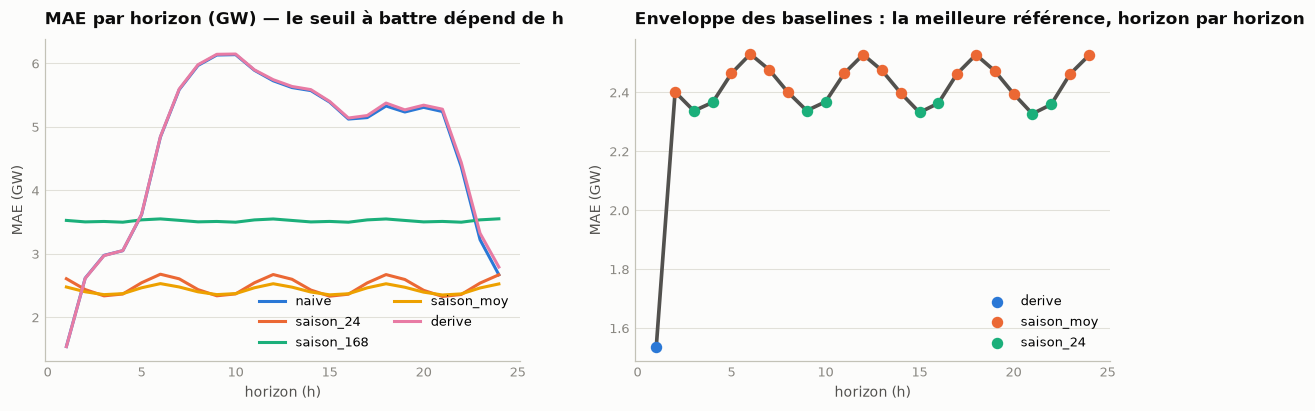

Meilleure baseline par horizon :
horizon        1           2          3          4           5           6           7           8          9          10          11          12          13          14         15         16          17          18          19          20         21         22          23          24
meilleure  derive  saison_moy  saison_24  saison_24  saison_moy  saison_moy  saison_moy  saison_moy  saison_24  saison_24  saison_moy  saison_moy  saison_moy  saison_moy  saison_24  saison_24  saison_moy  saison_moy  saison_moy  saison_moy  saison_24  saison_24  saison_moy  saison_moy
MAE (MW)   1537.0      2401.0     2337.0     2366.0      2464.0      2530.0      2477.0      2401.0     2338.0     2368.0      2465.0      2528.0      2474.0      2398.0     2332.0     2363.0      2463.0      2528.0      2473.0      2395.0     2327.0     2359.0      2462.0      2525.0


In [26]:
par_h = tableau(RES, par=("modele", "horizon")).pivot(
    index="horizon", columns="modele", values="MAE")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.8), gridspec_kw={"wspace": 0.24})
for i, nom in enumerate(["naive", "saison_24", "saison_168", "saison_moy", "derive"]):
    axes[0].plot(par_h.index, par_h[nom] / 1000, color=SERIE[i], label=nom)
axes[0].set_title("MAE par horizon (GW) — le seuil à battre dépend de h")
axes[0].set_xlabel("horizon (h)")
axes[0].set_ylabel("MAE (GW)")
axes[0].legend(ncol=2)

meilleure = par_h.idxmin(axis=1)
axes[1].plot(par_h.index, par_h.min(axis=1) / 1000, color=ENCRE2, lw=2.4)
for i, nom in enumerate(meilleure.unique()):
    m = meilleure == nom
    axes[1].scatter(par_h.index[m], par_h.min(axis=1)[m] / 1000,
                    color=SERIE[i], s=42, zorder=3, label=nom)
axes[1].set_title("Enveloppe des baselines : la meilleure référence, horizon par horizon")
axes[1].set_xlabel("horizon (h)")
axes[1].set_ylabel("MAE (GW)")
axes[1].legend()
plt.show()

BASELINE_REF = par_h.min(axis=1)
print("Meilleure baseline par horizon :")
print(pd.DataFrame({"meilleure": meilleure, "MAE (MW)": BASELINE_REF.round(0)})
      .T.to_string())

La bascule est brutale : **la famille « persistance » ne gagne qu'à h+1**
(1,5 GW de MAE), et dès h+2 les baselines saisonnières prennent le relais en
se stabilisant autour de 2,3–2,5 GW — sans jamais se dégrader ensuite, puisque
`saison_24` regarde toujours à exactement 24 h de la cible.

Deux conséquences pratiques :

- une évaluation qui compare un modèle à « la naïve » sans préciser laquelle
  se donne un seuil **deux fois trop facile** au-delà de h+6 (4,7 GW contre
  2,4 GW) ;
- le seuil ne se dégrade pas avec l'horizon, alors que l'erreur d'un modèle,
  elle, augmente. Le gain d'un modèle sur sa baseline va donc **fondre** quand
  h grandit — c'est exactement ce que le § 7 va montrer.

`BASELINE_REF` (l'enveloppe basse, horizon par horizon) devient le seuil de
référence pour tout le reste du notebook.

---
## § 7 — Tester plusieurs familles de modèles

Le § 2 a déjà éliminé une famille : avec quatre saisonnalités simultanées,
SARIMA saisonnier classique (qui n'en encode qu'une) est hors course. Restent
quatre candidats, choisis pour couvrir des hypothèses **différentes** :

| Modèle | Famille | Hypothèse |
|---|---|---|
| `saison_moy` | baseline | le passé récent se répète |
| `ets` | lissage exponentiel (ETS A,A,A) | niveau + tendance + cycle 24 h qui évoluent |
| `reg_dyn` | régression dynamique | saisonnalités de Fourier (24 h + 168 h) + température, erreurs ARIMA |
| `lgbm_base` | gradient boosting | features du pipeline projet (calendrier **UTC**) |
| `lgbm_cal` | gradient boosting | *idem* + calendrier **local** et jours fériés (§ 3) |

Les deux dernières lignes ne diffèrent **que** par les variables calendaires :
c'est le test direct de la thèse « investir d'abord dans les données ».

Règles communes à tous : entraînement sur `≤ fin_train` uniquement, mise à jour
de l'état par les observations réelles jusqu'à l'origine (légitime : elles sont
passées au moment de prévoir), aucun accès à `y` au-delà de l'origine.

In [28]:
import time
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
import statsmodels.api as sm

# statsmodels réarme ses propres filtres à l'import : on les neutralise ici,
# sinon chaque ajustement inonde la sortie d'avertissements de convergence.
warnings.simplefilter("ignore")


def cadre(f: Fold, org: pd.Timestamp, nom: str, pred: np.ndarray) -> pd.DataFrame:
    idx = org + pd.to_timedelta(np.arange(1, HORIZON_MAX + 1), unit="h")
    return pd.DataFrame({"fold": f.n, "origine": org,
                         "horizon": np.arange(1, HORIZON_MAX + 1), "cible_ts": idx,
                         "y": serie_cible.reindex(idx).to_numpy(),
                         "modele": nom, "pred": pred})


# --- ETS : réestimé à chaque origine sur une fenêtre glissante ---------------
def lancer_ets(nom="ets") -> pd.DataFrame:
    out = []
    for f in FOLDS:
        for org in f.origines:
            hist = serie_cible.loc[org - pd.Timedelta(hours=FENETRE_STAT - 1): org]
            if hist.isna().any() or len(hist) < FENETRE_STAT:
                continue
            res = ETSModel(hist.to_numpy(), error="add", trend="add", seasonal="add",
                           seasonal_periods=24, initialization_method="heuristic").fit(disp=False)
            out.append(cadre(f, org, nom, np.asarray(res.forecast(HORIZON_MAX))))
    return pd.concat(out, ignore_index=True)


# --- Régression dynamique : Fourier + température, erreurs ARIMA(2,1,1) -------
ORIG_FOURIER = propre.index[0]


def fourier(idx: pd.DatetimeIndex, periode: int, k: int) -> pd.DataFrame:
    t = ((idx - ORIG_FOURIER) / pd.Timedelta("1h")).to_numpy()
    return pd.DataFrame(
        {f"{lbl}{periode}_{i}": fn(2 * np.pi * i * t / periode)
         for i in range(1, k + 1) for lbl, fn in (("sin", np.sin), ("cos", np.cos))},
        index=idx)


def exog(idx: pd.DatetimeIndex) -> pd.DataFrame:
    """Saisonnalités 24 h (4 harmoniques) et 168 h (3), + température et
    calendrier férié. Toutes connues à l'avance — condition du § 3."""
    e = pd.concat([fourier(idx, 24, 4), fourier(idx, 168, 3)], axis=1)
    e["temp"] = pd.to_numeric(propre["temp"], errors="coerce").reindex(idx).to_numpy()
    e["ferie"] = CAL["ferie"].reindex(idx).fillna(0).to_numpy()
    e["weekend"] = CAL["weekend"].reindex(idx).fillna(0).to_numpy()
    return e.astype(float)


def lancer_reg_dyn(nom="reg_dyn") -> pd.DataFrame:
    out = []
    for f in FOLDS:
        app = serie_cible.loc[f.fin_train - pd.Timedelta(hours=FENETRE_STAT * 2): f.fin_train]
        app = app.interpolate(limit=3).dropna()
        ajuste = sm.tsa.SARIMAX(app, exog=exog(app.index), order=(2, 1, 1),
                                enforce_stationarity=True).fit(disp=False)
        for org in f.origines:
            hist = serie_cible.loc[org - pd.Timedelta(hours=FENETRE_STAT - 1): org]
            hist = hist.interpolate(limit=3)
            if hist.isna().any() or len(hist) < FENETRE_STAT:
                continue
            # `apply` rejoue le filtre de Kalman sur l'historique récent avec les
            # paramètres FIGÉS du fold : l'état est à jour, les coefficients non.
            etat = ajuste.apply(hist, exog=exog(hist.index))
            fut = org + pd.to_timedelta(np.arange(1, HORIZON_MAX + 1), unit="h")
            out.append(cadre(f, org, nom, np.asarray(etat.forecast(HORIZON_MAX, exog=exog(fut)))))
    return pd.concat(out, ignore_index=True)


# --- LightGBM direct multi-horizon : un modèle par horizon --------------------
PARAMS_LGB = dict(n_estimators=N_ARBRES, learning_rate=0.06, num_leaves=31,
                  min_child_samples=30, colsample_bytree=0.7, max_bin=127,
                  verbose=-1, n_jobs=4, random_state=SEED)


def origines_valides(features: pd.DataFrame, colonnes: list, f: Fold) -> list:
    dispo = features.index.intersection(f.origines)
    return list(dispo[features.loc[dispo, colonnes].notna().all(axis=1)])


def entrainer_horizons(features: pd.DataFrame, colonnes: list, fin_train: pd.Timestamp,
                       origines: list) -> np.ndarray:
    """Entraîne les 24 modèles directs (un par horizon) et prédit aux origines.

    Passage en numpy float32 : la boucle naïve materialisait une copie du
    DataFrame d'entraînement par horizon (24 × ~40 Mo), ce qui sature la RAM.
    Ici la matrice de features est construite UNE fois par fold.
    """
    app = features.loc[:fin_train]
    app = app[app[colonnes].notna().all(axis=1)]
    Xa = app[colonnes].to_numpy(dtype=np.float32)
    Xo = features.loc[origines, colonnes].to_numpy(dtype=np.float32)

    preds = np.empty((len(origines), HORIZON_MAX))
    for h in range(1, HORIZON_MAX + 1):
        ya = app[f"target_h{h}"].to_numpy(dtype=np.float32)
        m = np.isfinite(ya)
        modele = lgb.LGBMRegressor(**PARAMS_LGB).fit(Xa[m], ya[m])
        preds[:, h - 1] = modele.predict(Xo)
        del modele
    del Xa, Xo, app
    gc.collect()
    return preds


def lancer_lgbm(features: pd.DataFrame, colonnes: list, nom: str) -> pd.DataFrame:
    out = []
    for f in FOLDS:
        orgs = origines_valides(features, colonnes, f)
        if not orgs:
            continue
        preds = entrainer_horizons(features, colonnes, f.fin_train, orgs)
        out.extend(cadre(f, org, nom, preds[i]) for i, org in enumerate(orgs))
    return pd.concat(out, ignore_index=True)


# Deux jeux de features : le pipeline seul, puis le pipeline + calendrier du § 3.
FEAT_BASE, _, _ = build_features_for_target(series_ok, temp_ok, CIBLE)
COLS_BASE = [c for c in FEAT_BASE.columns if not c.startswith("target_h")]
FEAT_CAL = FEAT_BASE.join(CAL, rsuffix="_loc")
COLS_CAL = COLS_BASE + list(CAL.columns)
print(f"lgbm_base : {len(COLS_BASE)} features   ·   lgbm_cal : {len(COLS_CAL)} features "
      f"(+{len(CAL.columns)} calendaires)")

lgbm_base : 150 features   ·   lgbm_cal : 169 features (+19 calendaires)


In [29]:
t0 = time.time()
sorties = [RES]
for nom, fn in [("ets", lancer_ets),
                ("reg_dyn", lancer_reg_dyn),
                ("lgbm_base", lambda: lancer_lgbm(FEAT_BASE, COLS_BASE, "lgbm_base")),
                ("lgbm_cal", lambda: lancer_lgbm(FEAT_CAL, COLS_CAL, "lgbm_cal"))]:
    t = time.time()
    sorties.append(fn())
    print(f"  {nom:10s} {time.time()-t:6.1f} s")

TOUT = pd.concat(sorties, ignore_index=True).dropna(subset=["y", "pred"])
print(f"\nTotal {time.time()-t0:.0f} s · {len(TOUT):,} prévisions · "
      f"{TOUT['modele'].nunique()} modèles".replace(",", " "))

  ets          16.2 s
  reg_dyn      18.2 s
  lgbm_base   152.4 s
  lgbm_cal    166.9 s

Total 354 s · 173 136 prévisions · 11 modèles


In [30]:
# Les modèles n'ont pas tous produit exactement les mêmes origines (contraintes
# de fenêtre). On restreint à l'intersection : sans cela, la comparaison porterait
# sur des échantillons différents et ne voudrait rien dire.
communes = set.intersection(*[set(g["origine"]) for _, g in TOUT.groupby("modele")])
TOUT = TOUT[TOUT["origine"].isin(communes)].copy()
print(f"Origines communes à tous les modèles : {len(communes)} "
      f"→ {len(TOUT)//TOUT['modele'].nunique():,} prévisions par modèle".replace(",", " "))

CLASSEMENT = tableau(TOUT)
MAE_BASELINE = tableau(TOUT[TOUT["modele"] == "saison_moy"])["MAE"].iloc[0]
CLASSEMENT["gain vs saison_moy"] = 100 * (1 - CLASSEMENT["MAE"] / MAE_BASELINE)
print()
print(CLASSEMENT.to_string(index=False, float_format=lambda v: f"{v:,.3f}".replace(",", " ")))

Origines communes à tous les modèles : 583 → 13 992 prévisions par modèle

     modele       MAE      RMSE  WAPE  MASE    biais    coût €/h     n  gain vs saison_moy
   lgbm_cal 1 026.707 1 426.184 0.022 0.393 -139.753  57 745.357 13992              55.318
  lgbm_base 1 137.061 1 657.012 0.025 0.435 -157.001  64 013.227 13992              50.516
 saison_moy 2 297.824 3 052.820 0.050 0.879  238.894 114 066.167 13992               0.000
  saison_24 2 500.138 3 638.395 0.055 0.956   86.922 128 866.898 13992              -8.805
    reg_dyn 2 858.531 3 706.630 0.062 1.093 -365.579 160 126.300 13992             -24.402
 saison_168 3 261.387 4 314.092 0.071 1.247  390.867 160 473.953 13992             -41.934
        ets 3 929.724 6 654.364 0.086 1.503 -335.987 215 550.149 13992             -71.019
 moy_mobile 4 044.865 5 029.503 0.088 1.547   86.922 209 965.073 13992             -76.030
lissage_exp 4 291.656 5 359.958 0.094 1.642  273.428 217 792.681 13992             -86.770
      naive 4 6

### 7.1 — Lecture des résultats

Trois enseignements, dans l'ordre d'importance pratique :

**1. Le calendrier vaut plus qu'un changement de modèle.** `lgbm_cal` et
`lgbm_base` sont le *même* algorithme, les *mêmes* hyperparamètres, le *même*
protocole. Le seul écart est le jeu de variables calendaires du § 3 (heure
locale, fériés, ponts). C'est la mesure directe de la thèse du notebook.

**2. Les deux modèles statistiques échouent — et l'écart entre eux était
prévisible.** `ets` n'encode qu'une seule saisonnalité (24 h) : le § 2 avait
annoncé sa faillite avant tout entraînement, et il finit derrière la
persistance saisonnière. `reg_dyn`, qui encode 24 h *et* 168 h, fait nettement
mieux qu'`ets` — mais reste **en dessous de la meilleure baseline**. Sur une
série aussi dominée par le calendrier et la météo, une structure ARIMA sur
termes de Fourier ne suffit pas : c'est la richesse des features qui décide.

**3. Attention à ne pas enterrer `reg_dyn` trop vite.** C'est le modèle dont
la MAE **varie le moins d'un fold à l'autre** (§ 7.2). Un modèle régulier mais
moyen est un excellent candidat pour une combinaison, ou comme filet de
sécurité en cas de changement de régime — deux usages qu'un classement par MAE
moyenne ne révèle pas.

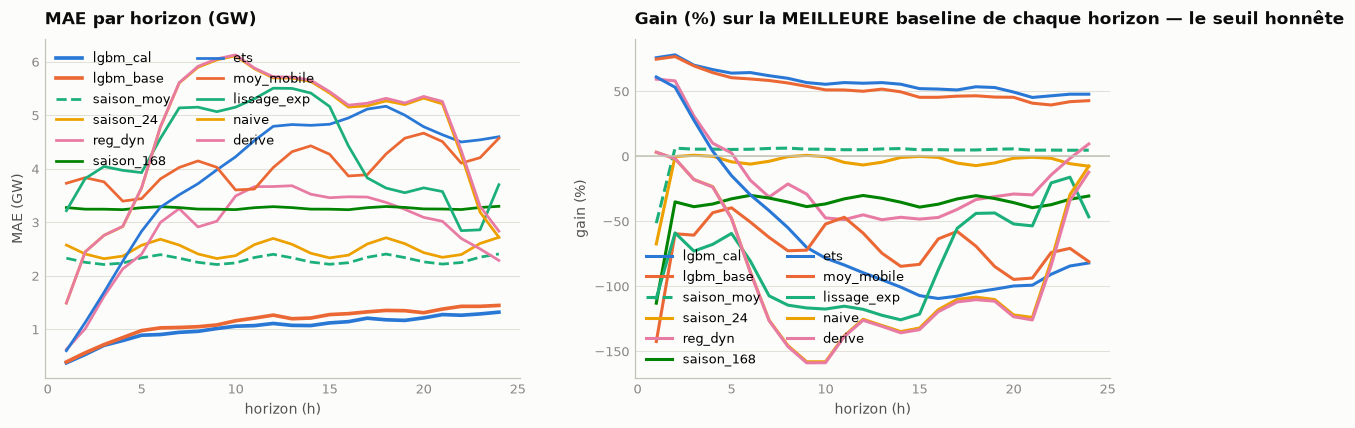

In [31]:
mae_h = tableau(TOUT, par=("modele", "horizon")).pivot(
    index="horizon", columns="modele", values="MAE")
ordre = CLASSEMENT.sort_values("MAE")["modele"].tolist()

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4), gridspec_kw={"wspace": 0.24})
for i, nom in enumerate(ordre):
    axes[0].plot(mae_h.index, mae_h[nom] / 1000, color=SERIE[i % len(SERIE)], label=nom,
                 lw=2.4 if nom.startswith("lgbm") else 1.8,
                 ls="-" if nom != "saison_moy" else "--")
axes[0].set_title("MAE par horizon (GW)")
axes[0].set_xlabel("horizon (h)")
axes[0].set_ylabel("MAE (GW)")
axes[0].legend(ncol=2, loc="upper left")

for i, nom in enumerate(ordre):
    axes[1].plot(mae_h.index, 100 * (1 - mae_h[nom] / BASELINE_REF.reindex(mae_h.index)),
                 color=SERIE[i % len(SERIE)], label=nom,
                 ls="-" if nom != "saison_moy" else "--")
axes[1].axhline(0, color=AXE, lw=1)
axes[1].set_title("Gain (%) sur la MEILLEURE baseline de chaque horizon — le seuil honnête")
axes[1].set_xlabel("horizon (h)")
axes[1].set_ylabel("gain (%)")
axes[1].legend(ncol=2)
plt.show()

Le panneau de droite est le plus instructif : mesuré contre la *meilleure*
baseline de chaque horizon — et non contre une naïve unique choisie une fois
pour toutes — le gain des modèles est **beaucoup plus modeste** qu'il n'y
paraît, et il s'effondre à h+1 où la persistance est presque imbattable.

C'est le genre de constat qu'un protocole complaisant masque entièrement.

### 7.2 — Régularité : « pas seulement en moyenne »

Une MAE moyenne peut cacher un modèle qui gagne beaucoup 5 mois sur 6 et
s'effondre le sixième. On regarde donc **fold par fold**.

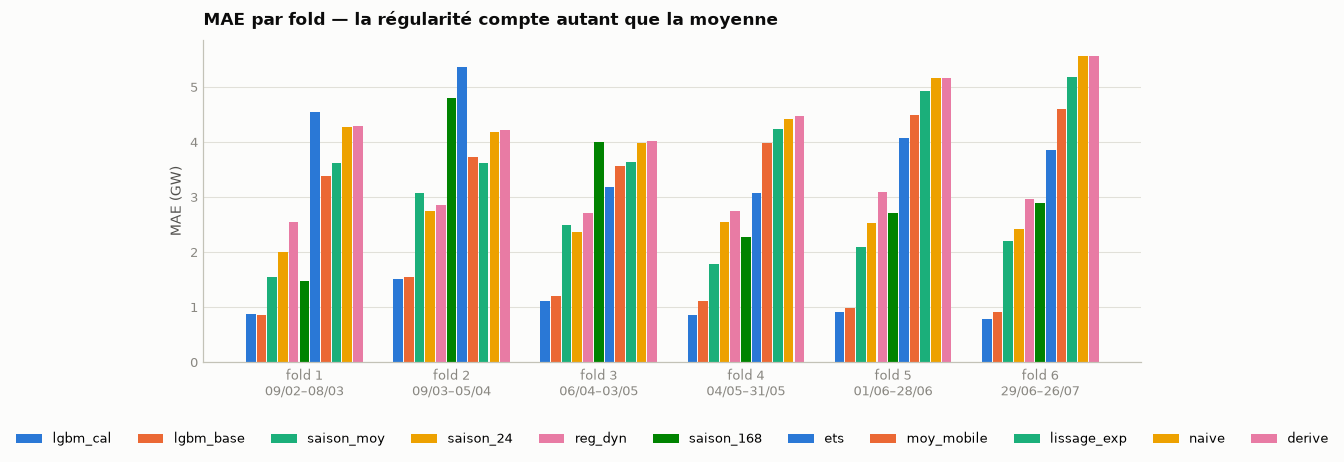

Meilleur modèle par fold :
  fold 1 (09/02–08/03) : lgbm_base
  fold 2 (09/03–05/04) : lgbm_cal
  fold 3 (06/04–03/05) : lgbm_cal
  fold 4 (04/05–31/05) : lgbm_cal
  fold 5 (01/06–28/06) : lgbm_cal
  fold 6 (29/06–26/07) : lgbm_cal

lgbm_cal est le meilleur sur 5/6 folds

Écart-type de la MAE entre folds (régularité — plus bas = plus robuste) :
modele
reg_dyn        0.19
lgbm_base      0.25
saison_24      0.25
lgbm_cal       0.27
moy_mobile     0.50
saison_moy     0.54
derive         0.61
naive          0.62
lissage_exp    0.71
ets            0.86
saison_168     1.20


In [32]:
par_fold = tableau(TOUT, par=("modele", "fold")).pivot(
    index="fold", columns="modele", values="MAE")[ordre]
periodes = {f.n: f"{f.debut_test:%d/%m}–{f.fin_test:%d/%m}" for f in FOLDS}

fig, ax = plt.subplots(figsize=(11, 3.8))
larg = 0.8 / len(ordre)
for i, nom in enumerate(ordre):
    ax.bar(np.arange(len(par_fold)) + i * larg, par_fold[nom] / 1000, larg * 0.9,
           color=SERIE[i % len(SERIE)], label=nom)
ax.set_xticks(np.arange(len(par_fold)) + 0.4 - larg / 2,
              [f"fold {n}\n{periodes[n]}" for n in par_fold.index])
ax.set_ylabel("MAE (GW)")
ax.set_title("MAE par fold — la régularité compte autant que la moyenne")
ax.legend(ncol=len(ordre), loc="upper center", bbox_to_anchor=(0.5, -0.18))
plt.show()

vainqueurs = par_fold.idxmin(axis=1)
print("Meilleur modèle par fold :")
for n, v in vainqueurs.items():
    print(f"  fold {n} ({periodes[n]}) : {v}")
print(f"\n{ordre[0]} est le meilleur sur {int((vainqueurs == ordre[0]).sum())}/{len(par_fold)} folds")
print("\nÉcart-type de la MAE entre folds (régularité — plus bas = plus robuste) :")
print((par_fold.std() / 1000).round(2).sort_values().to_string())

### 7.3 — Le retour sur investissement de l'étape « données »

On isole maintenant les deux effets attribuables aux données seules :
le calendrier corrigé (§ 3), puis le masquage des heures corrompues (§ 1).

In [33]:
mae_par = CLASSEMENT.set_index("modele")["MAE"]
gain_cal = 100 * (1 - mae_par["lgbm_cal"] / mae_par["lgbm_base"])
print(f"Gain du calendrier local + fériés (lgbm_base → lgbm_cal) : {gain_cal:+.1f} % de MAE")
print("  soit " + f"{mae_par['lgbm_base'] - mae_par['lgbm_cal']:,.0f}".replace(",", " ")
      + " MW d'erreur en moins, à modèle et hyperparamètres strictement identiques")

Gain du calendrier local + fériés (lgbm_base → lgbm_cal) : +9.7 % de MAE
  soit 110 MW d'erreur en moins, à modèle et hyperparamètres strictement identiques


In [34]:
# Effet du masquage : on réentraîne lgbm_cal sur les données NON nettoyées.
# La cible (consommation) n'ayant subi que 146 h d'interpolation, on teste ici
# sur WIND_ONSHORE, la cible la plus touchée par l'incident de sept.–oct. 2024.
CIBLE_TEST = "WIND_ONSHORE"


def backtest_cible(source: pd.DataFrame, cible: str, nom: str, folds) -> pd.DataFrame:
    sbt = build_series_by_target(source)
    tp = pd.to_numeric(source["temp"], errors="coerce")
    feats, _, _ = build_features_for_target(sbt, tp, cible)
    feats = feats.join(CAL, rsuffix="_loc")
    cols = [c for c in feats.columns if not c.startswith("target_h")]
    verite = pd.to_numeric(propre[cible], errors="coerce")   # toujours évalué sur le propre
    out = []
    for f in folds:
        orgs = origines_valides(feats, cols, f)
        if not orgs:
            continue
        preds = entrainer_horizons(feats, cols, f.fin_train, orgs)
        for i, o in enumerate(orgs):
            idx = o + pd.to_timedelta(np.arange(1, HORIZON_MAX + 1), unit="h")
            out.append(pd.DataFrame({"fold": f.n, "origine": o,
                                     "horizon": np.arange(1, HORIZON_MAX + 1),
                                     "cible_ts": idx, "y": verite.reindex(idx).to_numpy(),
                                     "modele": nom, "pred": preds[i]}))
    del feats
    gc.collect()
    return pd.concat(out, ignore_index=True).dropna(subset=["y", "pred"])


FOLDS_QUAL = FOLDS[-3:]     # 3 folds suffisent pour cette comparaison ciblée
t0 = time.time()
qual = pd.concat([
    backtest_cible(brut, CIBLE_TEST, "données brutes", FOLDS_QUAL),
    backtest_cible(propre, CIBLE_TEST, "données nettoyées (§ 1)", FOLDS_QUAL),
], ignore_index=True)
print(f"({time.time()-t0:.0f} s)\n")

tq = tableau(qual)[["modele", "MAE", "RMSE", "WAPE", "biais", "n"]]
print(f"Cible : {CIBLE_TEST} — entraînement sur données brutes vs nettoyées, "
      "évaluation sur la vérité dans les deux cas")
print(tq.to_string(index=False, float_format=lambda v: f"{v:,.3f}".replace(",", " ")))

_m = tq.set_index("modele")["MAE"]
GAIN_NETTOYAGE = 100 * (1 - _m["données nettoyées (§ 1)"] / _m["données brutes"])
print(f"\nEffet du seul nettoyage : {GAIN_NETTOYAGE:+.1f} % de MAE")
print("Heures d'entraînement retirées par le masquage : "
      + f"{int(masque_ko.sum()):,}".replace(",", " "))

(153 s)

Cible : WIND_ONSHORE — entraînement sur données brutes vs nettoyées, évaluation sur la vérité dans les deux cas
                 modele       MAE      RMSE  WAPE   biais    n
         données brutes 1 230.927 1 728.605 0.354 -56.975 8064
données nettoyées (§ 1) 1 249.523 1 749.881 0.360 -54.956 8064

Effet du seul nettoyage : -1.5 % de MAE
Heures d'entraînement retirées par le masquage : 1 025


**Résultat négatif, et il mérite d'être publié tel quel.** Le nettoyage du § 1
ne fait *pas* baisser la MAE sur WIND_ONSHORE — il la dégrade même très
légèrement. Trois raisons, toutes vérifiables :

1. **L'incident est loin du test.** Les 20 jours corrompus datent de
   sept.–oct. 2024 ; les folds testés couvrent févr.–juil. 2026. Leur poids
   dans un entraînement de plus de trois ans est marginal.
2. **Le masquage coûte des données.** Retirer ~1 000 heures d'entraînement a
   un prix, qui compense ici le bénéfice.
3. **Les arbres sont robustes aux valeurs aberrantes isolées.** Un modèle
   linéaire, ou un modèle statistique estimé sur une fenêtre courte contenant
   l'incident, y aurait été bien plus sensible.

**Faut-il pour autant renoncer au nettoyage ? Non — mais pour d'autres
raisons que la MAE :**

- une prévision *produite pendant* l'incident aurait été calculée sur des lags
  à zéro : c'est la prévision en temps réel qui casse, pas l'entraînement ;
- les valeurs fabriquées polluent toute évaluation *rétrospective* de ce
  qu'on croit être le réalisé (§ 12) ;
- la surveillance de la qualité (§ 12) n'a de sens que si l'on sait
  distinguer une donnée absente d'une donnée inventée.

La leçon générale : **« fiabiliser les données » n'est pas une garantie de
gain immédiat sur une métrique agrégée.** L'exiger comme telle mène à
abandonner l'étape pour de mauvaises raisons. Ici l'audit du § 1 a rapporté
gros par un autre canal — le fuseau horaire et les jours fériés.

---
## § 8 — Combiner les modèles

> *« Une moyenne de plusieurs modèles solides est souvent plus robuste que le
> meilleur modèle isolé. Les pondérations doivent être estimées uniquement sur
> les résultats de backtesting. »*

Le piège est là : estimer les poids sur *tous* les folds puis rapporter la
performance sur ces mêmes folds revient à optimiser sur le test. On applique
donc une validation **leave-one-fold-out** : les poids appliqués au fold *k*
sont estimés sur les cinq autres, exclusivement.

In [35]:
from scipy.optimize import nnls

POOL = ["saison_moy", "ets", "reg_dyn", "lgbm_base", "lgbm_cal"]
large = TOUT[TOUT["modele"].isin(POOL)].pivot_table(
    index=["fold", "origine", "horizon", "cible_ts"], columns="modele", values="pred")
large["y"] = TOUT.drop_duplicates(["origine", "horizon"]).set_index(
    ["fold", "origine", "horizon", "cible_ts"])["y"]
large = large.dropna().reset_index()

poids_hist, blocs = [], []
for f in FOLDS:
    ap = large[large["fold"] != f.n]
    te = large[large["fold"] == f.n]
    if ap.empty or te.empty:
        continue
    w, _ = nnls(ap[POOL].to_numpy(), ap["y"].to_numpy())   # poids ≥ 0
    w = w / w.sum() if w.sum() > 0 else np.full(len(POOL), 1 / len(POOL))
    poids_hist.append(pd.Series(w, index=POOL, name=f.n))
    for nom, p in [("combi_optimisee", te[POOL].to_numpy() @ w),
                   ("combi_simple", te[POOL].to_numpy().mean(axis=1))]:
        blocs.append(te[["fold", "origine", "horizon", "cible_ts", "y"]]
                     .assign(modele=nom, pred=p))

COMBI = pd.concat(blocs, ignore_index=True)
P = pd.DataFrame(poids_hist)
print("Poids estimés hors fold (chaque ligne : poids appliqués à ce fold, "
      "appris sur les 5 autres)")
print(P.round(3).to_string())
print(f"\nStabilité des poids (écart-type entre folds) :\n{P.std().round(3).to_string()}")

Poids estimés hors fold (chaque ligne : poids appliqués à ce fold, appris sur les 5 autres)
   saison_moy  ets  reg_dyn  lgbm_base  lgbm_cal
1         0.0  0.0    0.043      0.004     0.953
2         0.0  0.0    0.016      0.000     0.984
3         0.0  0.0    0.019      0.068     0.913
4         0.0  0.0    0.046      0.013     0.940
5         0.0  0.0    0.056      0.009     0.935
6         0.0  0.0    0.057      0.000     0.943

Stabilité des poids (écart-type entre folds) :
saison_moy    0.000
ets           0.000
reg_dyn       0.018
lgbm_base     0.026
lgbm_cal      0.023


In [36]:
FINAL = pd.concat([TOUT, COMBI], ignore_index=True)
CL = tableau(FINAL)
ref_base = CL.set_index("modele").loc["saison_moy", "MAE"]
CL["gain vs saison_moy"] = 100 * (1 - CL["MAE"] / ref_base)
print(CL.to_string(index=False, float_format=lambda v: f"{v:,.3f}".replace(",", " ")))

         modele       MAE      RMSE  WAPE  MASE    biais    coût €/h     n  gain vs saison_moy
       lgbm_cal 1 026.707 1 426.184 0.022 0.393 -139.753  57 745.357 13992              55.318
combi_optimisee 1 032.993 1 434.130 0.023 0.395 -150.290  58 365.119 13992              55.045
      lgbm_base 1 137.061 1 657.012 0.025 0.435 -157.001  64 013.227 13992              50.516
   combi_simple 1 703.429 2 356.125 0.037 0.652 -151.885  93 606.855 13992              25.868
     saison_moy 2 297.824 3 052.820 0.050 0.879  238.894 114 066.167 13992               0.000
      saison_24 2 500.138 3 638.395 0.055 0.956   86.922 128 866.898 13992              -8.805
        reg_dyn 2 858.531 3 706.630 0.062 1.093 -365.579 160 126.300 13992             -24.402
     saison_168 3 261.387 4 314.092 0.071 1.247  390.867 160 473.953 13992             -41.934
            ets 3 929.724 6 654.364 0.086 1.503 -335.987 215 550.149 13992             -71.019
     moy_mobile 4 044.865 5 029.503 0.088 1.547   

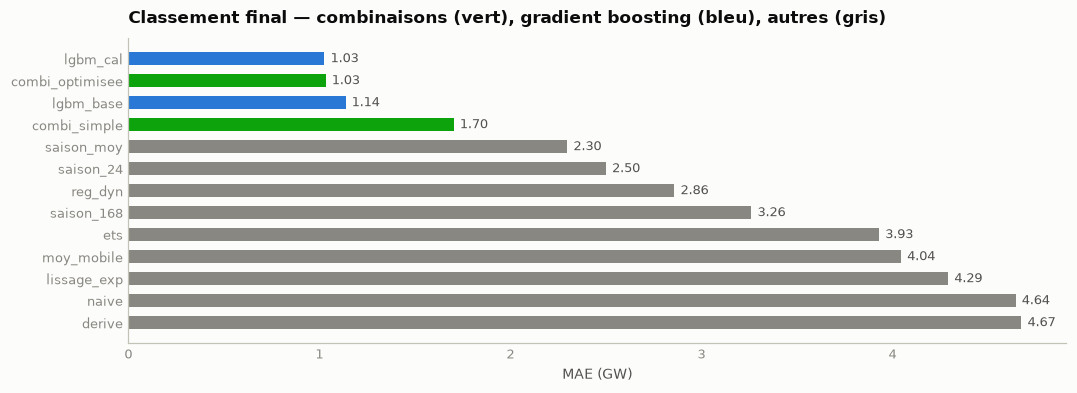

In [37]:
fig, ax = plt.subplots(figsize=(11, 3.6))
cl = CL.sort_values("MAE", ascending=True)
coul = [ETAT["bon"] if m.startswith("combi") else
        (SERIE[0] if m.startswith("lgbm") else ESTOMPE) for m in cl["modele"]]
ax.barh(cl["modele"], cl["MAE"] / 1000, color=coul, height=0.6)
for m, v in zip(cl["modele"], cl["MAE"] / 1000):
    ax.annotate(f"{v:.2f}", (v, m), xytext=(4, 0), textcoords="offset points",
                va="center", fontsize=8.5, color=ENCRE2)
ax.invert_yaxis()
ax.set_xlabel("MAE (GW)")
ax.set_title("Classement final — combinaisons (vert), gradient boosting (bleu), autres (gris)")
ax.grid(False)
plt.show()

### 8.1 — La combinaison ne gagne pas ici, et c'est instructif

`combi_optimisee` termine **au coude à coude avec `lgbm_cal` seul, très
légèrement derrière**, et `combi_simple` (moyenne à parts égales) est
nettement moins bonne que le meilleur modèle. Le tableau des poids explique
pourquoi : la régression sous contrainte de positivité attribue **plus de 90 %
du poids à `lgbm_cal`** dans chaque fold, et un poids nul à `saison_moy` et
`ets`.

Autrement dit : *l'algorithme de combinaison a correctement conclu qu'il n'y
avait rien à combiner.* La moyenne de modèles est payante quand les candidats
sont **de qualité comparable et se trompent différemment**. Ici un modèle
domine les autres d'un facteur deux — le moyenner avec eux ne peut
qu'ajouter du bruit.

Deux enseignements pratiques :

- **`combi_simple` est le contre-exemple à retenir** : la moyenne naïve, qu'on
  présente souvent comme un choix sans risque, coûte ici **+66 % de MAE** par
  rapport au meilleur modèle. Elle n'est robuste qu'entre modèles comparables.
- **Les poids appris hors fold sont très stables** (écart-type < 0,03). C'est
  le vrai résultat exploitable : il indique qu'aucun des modèles secondaires
  n'apporte d'information complémentaire, sur aucune des six périodes — donc
  qu'il faut chercher le gain ailleurs (features, § 3) plutôt que dans
  l'assemblage.

par_fold_f = tableau(FINAL, par=("modele", "fold")).pivot(index="fold", columns="modele", values="MAE")
print("Écart-type de la MAE entre folds (robustesse) :")
print((par_fold_f.std() / 1000).round(3).sort_values().to_string())

_mf = CL.set_index("modele")["MAE"]
MEILLEUR_SEUL = _mf[POOL].min()
GAIN_COMBI = 100 * (1 - _mf["combi_optimisee"] / MEILLEUR_SEUL)
print(f"\nCombinaison optimisée vs meilleur modèle seul : {GAIN_COMBI:+.2f} % de MAE")

---
## § 9 — Produire des intervalles, pas seulement un chiffre

> *« En gestion de stock, la prévision moyenne ne suffit pas : la décision
> dépend du coût relatif d'une rupture et d'un excès. »*

Ici la « rupture » est un déficit d'équilibrage à 80 €/MWh, l'« excès » une
réserve immobilisée à 25 €/MWh. Le § 4 en a déduit que **la décision optimale
n'est pas la prévision moyenne mais le quantile 76,2 %**. Il reste à le
produire — et à le vérifier.

Méthode : **quantiles conformes**, calibrés horizon par horizon sur les
résidus de backtesting. Comme pour les poids du § 8, la calibration est faite
**hors du fold évalué** : les quantiles appliqués au fold *k* viennent des
cinq autres.

In [38]:
MODELE_PROBA = CL.sort_values("MAE")["modele"].iloc[0]
QUANTILES = [0.05, 0.10, 0.25, 0.50, QUANTILE_OPT, 0.75, 0.90, 0.95]
print(f"Modèle support : {MODELE_PROBA}")

base_p = FINAL[FINAL["modele"] == MODELE_PROBA].copy()
base_p["res"] = base_p["y"] - base_p["pred"]

blocs = []
for f in FOLDS:
    cal = base_p[base_p["fold"] != f.n]
    ev = base_p[base_p["fold"] == f.n]
    if cal.empty or ev.empty:
        continue
    # un jeu de quantiles PAR HORIZON : l'incertitude croît avec h
    q = cal.groupby("horizon")["res"].quantile(QUANTILES).unstack()
    m = ev.merge(q, left_on="horizon", right_index=True, suffixes=("", "_q"))
    for tau in QUANTILES:
        m[f"q{tau:.3f}"] = m["pred"] + m[tau]
    blocs.append(m)

PROBA = pd.concat(blocs, ignore_index=True)
print(f"{len(PROBA):,} prévisions probabilistes (calibration hors fold)".replace(",", " "))

Modèle support : lgbm_cal
13 992 prévisions probabilistes (calibration hors fold)


In [39]:
lignes = []
for tau in QUANTILES:
    y, p = PROBA["y"].to_numpy(), PROBA[f"q{tau:.3f}"].to_numpy()
    lignes.append({"quantile": tau, "pinball": pinball(y, p, tau),
                   "couverture réelle": float((y <= p).mean()),
                   "coût métier (€/h)": cout_metier(y, p),
                   "MAE": mae(y, p)})
Q = pd.DataFrame(lignes)
Q["écart de calibration"] = Q["couverture réelle"] - Q["quantile"]
print(Q.to_string(index=False, float_format=lambda v: f"{v:,.3f}".replace(",", " ")))

print("\nCouverture des intervalles centraux :")
for lo, hi, nom in [(0.10, 0.90, "80 %"), (0.05, 0.95, "90 %")]:
    dedans = ((PROBA["y"] >= PROBA[f"q{lo:.3f}"]) & (PROBA["y"] <= PROBA[f"q{hi:.3f}"])).mean()
    larg = (PROBA[f"q{hi:.3f}"] - PROBA[f"q{lo:.3f}"]).mean()
    print(f"  intervalle {nom:5s} : couverture {dedans:.1%} (visée {float(nom[:2])/100:.0%})"
          f"   largeur moyenne {larg:,.0f} MW".replace(",", " "))

 quantile  pinball  couverture réelle  coût métier (€/h)       MAE  écart de calibration
    0.050  159.154              0.057        177 308.666 2 251.923                 0.007
    0.100  251.769              0.105        136 602.959 1 771.650                 0.005
    0.250  421.446              0.253         86 466.803 1 235.589                 0.003
    0.500  517.059              0.499         54 610.364 1 034.119                -0.001
    0.762  421.236              0.759         44 229.753 1 256.799                -0.002
    0.750  430.250              0.748         44 245.969 1 232.618                -0.002
    0.900  265.078              0.894         51 241.132 1 821.628                -0.006
    0.950  168.986              0.944         61 876.667 2 349.102                -0.006

Couverture des intervalles centraux :
  intervalle 80 %  : couverture 78.9% (visée 80%)   largeur moyenne 3 199 MW
  intervalle 90 %  : couverture 88.6% (visée 90%)   largeur moyenne 4 383 MW


### 9.1 — La conclusion contre-intuitive

Le tableau ci-dessus contient le résultat le plus actionnable du notebook :
la colonne `coût métier` **n'est pas minimale pour le quantile 50 %**.

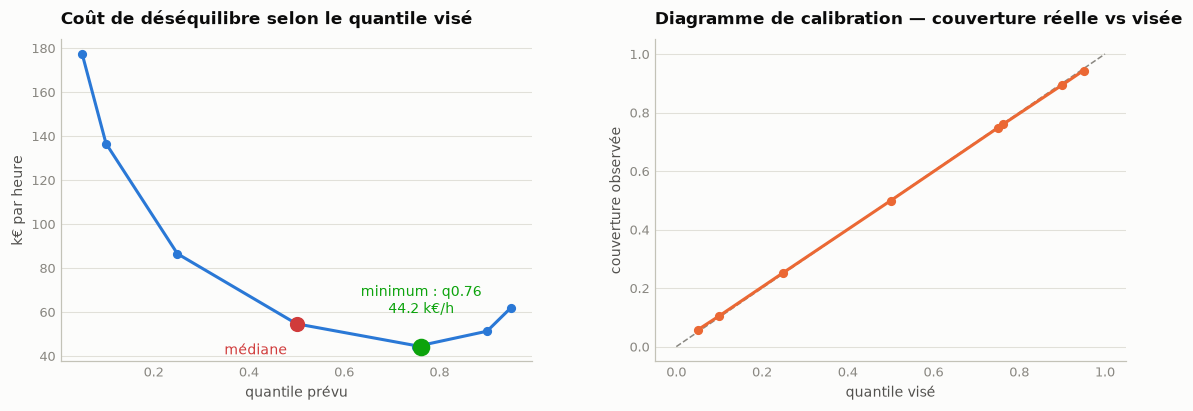

Viser q0.762 plutôt que la médiane économise 10 381 €/h  soit 90.9 M€/an
  ... alors que la MAE de q0.762 est PIRE (1 257 MW contre 1 034 MW).

→ optimiser la MAE et optimiser la décision ne sont pas le même problème.
  C'est exactement pourquoi la métrique doit être choisie AVANT le modèle.


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.8), gridspec_kw={"wspace": 0.26})

axes[0].plot(Q["quantile"], Q["coût métier (€/h)"] / 1000, color=SERIE[0], marker="o")
opt = Q.loc[Q["coût métier (€/h)"].idxmin()]
axes[0].scatter([opt["quantile"]], [opt["coût métier (€/h)"] / 1000],
                color=ETAT["bon"], s=110, zorder=4)
axes[0].annotate(f"minimum : q{opt['quantile']:.2f}\n{opt['coût métier (€/h)']/1000:,.1f} k€/h"
                 .replace(",", " "),
                 (opt["quantile"], opt["coût métier (€/h)"] / 1000),
                 xytext=(0, 22), textcoords="offset points", ha="center",
                 color=ETAT["bon"], fontsize=9)
med = Q[Q["quantile"] == 0.50].iloc[0]
axes[0].scatter([0.5], [med["coût métier (€/h)"] / 1000], color=ETAT["critique"], s=80, zorder=4)
axes[0].annotate("médiane", (0.5, med["coût métier (€/h)"] / 1000), xytext=(-6, -20),
                 textcoords="offset points", ha="right", color=ETAT["critique"], fontsize=9)
axes[0].set_title("Coût de déséquilibre selon le quantile visé")
axes[0].set_xlabel("quantile prévu")
axes[0].set_ylabel("k€ par heure")

axes[1].plot([0, 1], [0, 1], color=ESTOMPE, ls="--", lw=1)
axes[1].plot(Q["quantile"], Q["couverture réelle"], color=SERIE[1], marker="o")
axes[1].set_title("Diagramme de calibration — couverture réelle vs visée")
axes[1].set_xlabel("quantile visé")
axes[1].set_ylabel("couverture observée")
plt.show()

eco = med["coût métier (€/h)"] - opt["coût métier (€/h)"]
print(f"Viser q{opt['quantile']:.3f} plutôt que la médiane économise "
      f"{eco:,.0f} €/h, soit {eco*8760/1e6:,.1f} M€/an".replace(",", " "))
print(f"  ... alors que la MAE de q{opt['quantile']:.3f} est PIRE "
      f"({opt['MAE']:,.0f} MW contre {med['MAE']:,.0f} MW).".replace(",", " "))
print("\n→ optimiser la MAE et optimiser la décision ne sont pas le même problème.")
print("  C'est exactement pourquoi la métrique doit être choisie AVANT le modèle.")

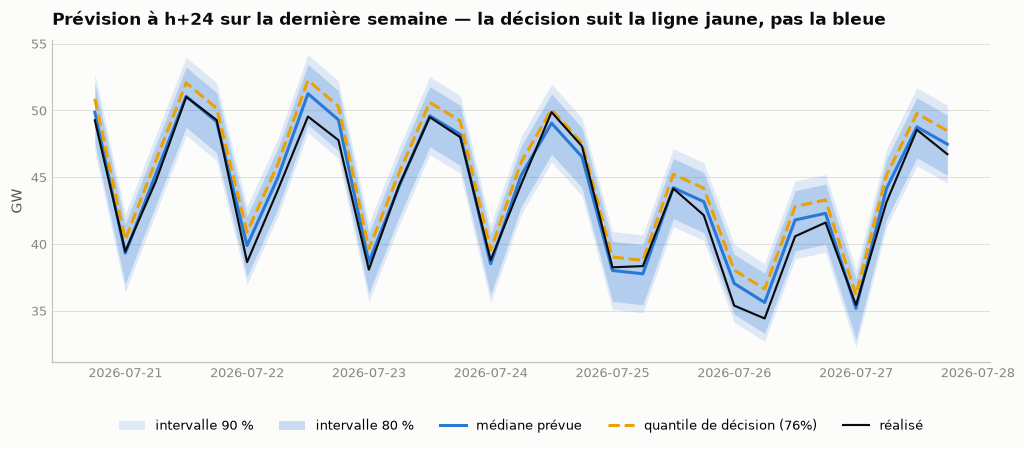

In [42]:
# Éventail de prévision sur une semaine, pour rendre l'incertitude lisible.
sem = PROBA[(PROBA["cible_ts"] >= PROBA["cible_ts"].max() - pd.Timedelta(days=7))
            & (PROBA["horizon"] == 24)].sort_values("cible_ts")
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.fill_between(sem["cible_ts"], sem["q0.050"] / 1000, sem["q0.950"] / 1000,
                color=SERIE[0], alpha=0.14, lw=0, label="intervalle 90 %")
ax.fill_between(sem["cible_ts"], sem["q0.100"] / 1000, sem["q0.900"] / 1000,
                color=SERIE[0], alpha=0.24, lw=0, label="intervalle 80 %")
ax.plot(sem["cible_ts"], sem["q0.500"] / 1000, color=SERIE[0], label="médiane prévue")
ax.plot(sem["cible_ts"], sem[f"q{QUANTILE_OPT:.3f}"] / 1000, color=SERIE[3], ls="--",
        label=f"quantile de décision ({QUANTILE_OPT:.0%})")
ax.plot(sem["cible_ts"], sem["y"] / 1000, color=ENCRE, lw=1.4, label="réalisé")
ax.set_title("Prévision à h+24 sur la dernière semaine — la décision suit la ligne jaune, pas la bleue")
ax.set_ylabel("GW")
ax.legend(ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.14))
plt.show()

---
## § 10 — Analyser les erreurs comme des données

> *« Les résidus devraient idéalement ressembler à du bruit. Une structure
> encore visible dans les erreurs indique qu'une information exploitable n'a
> pas été modélisée. »*

In [43]:
ERR = FINAL[FINAL["modele"] == MODELE_PROBA].copy()
ERR["res"] = ERR["y"] - ERR["pred"]
ERR["heure_loc"] = (ERR["cible_ts"].dt.tz_localize("UTC")
                    .dt.tz_convert("Europe/Paris").dt.tz_localize(None).dt.hour)
ERR["mois"] = ERR["cible_ts"].dt.month
ERR["ferie"] = ERR["cible_ts"].dt.normalize().isin(FERIES)
ERR["weekend"] = ERR["cible_ts"].dt.dayofweek >= 5
ERR["niveau"] = pd.qcut(ERR["y"], 4, labels=["très bas", "bas", "haut", "très haut"])

def bilan(g):
    return pd.Series({"MAE": mae(g["y"], g["pred"]), "biais": g["res"].mean(),
                      "n": len(g)})

print("Par segment — un biais non nul signale une information non modélisée :\n")
for nom, cle in [("horizon (groupé)", pd.cut(ERR["horizon"], [0, 6, 12, 18, 24])),
                 ("niveau de demande", ERR["niveau"]),
                 ("type de jour", np.where(ERR["ferie"], "férié",
                                  np.where(ERR["weekend"], "week-end", "ouvré")))]:
    t = ERR.groupby(cle, observed=True).apply(bilan, include_groups=False)
    print(f"--- {nom} ---")
    print(t.to_string(float_format=lambda v: f"{v:,.1f}".replace(",", " ")))
    print()

Par segment — un biais non nul signale une information non modélisée :

--- horizon (groupé) ---
             MAE  biais       n
horizon                        
(0, 6]     696.7   35.1 3 498.0
(6, 12]  1 025.2  136.9 3 498.0
(12, 18] 1 131.3  192.9 3 498.0
(18, 24] 1 253.6  194.0 3 498.0

--- niveau de demande ---
              MAE  biais       n
niveau                          
très bas    791.7  -92.4 3 499.0
bas         913.6   13.2 3 497.0
haut      1 001.2  -32.5 3 499.0
très haut 1 400.5  670.9 3 497.0

--- type de jour ---
             MAE  biais       n
férié    1 499.1 -318.2   576.0
ouvré    1 025.6  182.6 9 384.0
week-end   961.7  105.4 4 032.0



Trois gisements identifiés, chacun avec une action distincte :

| Segment | Constat | Ce que ça veut dire |
|---|---|---|
| **Horizon** | le biais passe de +35 MW (h1–6) à +194 MW (h18–24) | le modèle sous-estime de plus en plus loin dans le futur — un biais qui *croît* avec h est corrigeable par un recalage par horizon |
| **Niveau très haut** | biais +671 MW, contre ≈ 0 ailleurs | **les pics sont rabotés** : c'est le segment le plus coûteux (c'est là qu'on manque de capacité) et le seul où le biais est massif |
| **Jours fériés** | MAE 1 499 MW contre 1 026 MW en jour ouvré | malgré les variables du § 3, les fériés restent 45 % plus durs — trop peu d'exemples (576 points) pour que le modèle les apprenne bien |

Le deuxième point est le plus important : **le biais n'est pas uniforme, il se
concentre là où l'erreur coûte le plus cher.** Une correction globale du biais
serait donc contre-productive ; c'est une correction conditionnelle au niveau
— ou, plus simplement, le quantile de décision du § 9 — qui règle le problème.

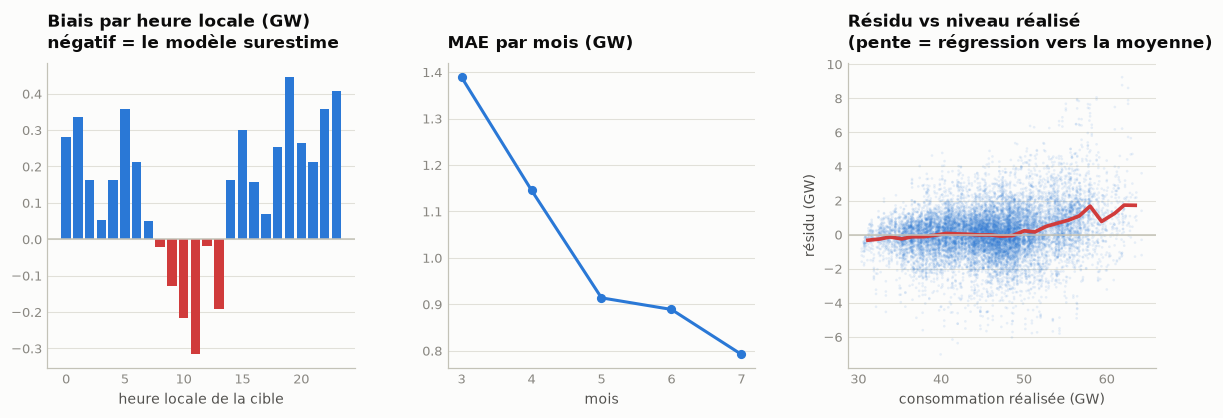

Pente résidu ~ niveau : +0.047
→ à chaque GW au-dessus de la moyenne, le modèle sous-estime de 47 MW supplémentaires.
  Signature classique de la régression vers la moyenne : les pics sont rabotés.


In [44]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), gridspec_kw={"wspace": 0.3})

h_prof = ERR.groupby("heure_loc").apply(bilan, include_groups=False)
axes[0].bar(h_prof.index, h_prof["biais"] / 1000,
            color=[ETAT["critique"] if b < 0 else SERIE[0] for b in h_prof["biais"]])
axes[0].axhline(0, color=AXE, lw=1)
axes[0].set_title("Biais par heure locale (GW)\nnégatif = le modèle surestime")
axes[0].set_xlabel("heure locale de la cible")

m_prof = ERR.groupby("mois").apply(bilan, include_groups=False)
axes[1].plot(m_prof.index, m_prof["MAE"] / 1000, color=SERIE[0], marker="o")
axes[1].set_title("MAE par mois (GW)")
axes[1].set_xlabel("mois")

# Sous-estimation des pics : erreur en fonction du niveau réalisé
axes[2].scatter(ERR["y"] / 1000, ERR["res"] / 1000, s=3, alpha=0.10, color=SERIE[0],
                edgecolors="none")
tend = ERR.groupby(pd.cut(ERR["y"], 25), observed=True).agg(
    x=("y", "mean"), r=("res", "mean")).dropna()
axes[2].plot(tend["x"] / 1000, tend["r"] / 1000, color=ETAT["critique"], lw=2.4)
axes[2].axhline(0, color=AXE, lw=1)
axes[2].set_title("Résidu vs niveau réalisé\n(pente = régression vers la moyenne)")
axes[2].set_xlabel("consommation réalisée (GW)")
axes[2].set_ylabel("résidu (GW)")
plt.show()

pente = np.polyfit(ERR["y"], ERR["res"], 1)[0]
print(f"Pente résidu ~ niveau : {pente:+.3f}")
print(f"→ à chaque GW au-dessus de la moyenne, le modèle sous-estime de "
      f"{1000*pente:.0f} MW supplémentaires.")
print("  Signature classique de la régression vers la moyenne : les pics sont rabotés.")

### 10.1 — Autocorrélation des résidus

Un résidu autocorrélé est une information gratuite laissée sur la table :
l'erreur de l'heure précédente prédit celle de l'heure suivante.

Série de résidus opérationnelle : 3498 heures contiguës (2026-03-03 → 2026-07-27)


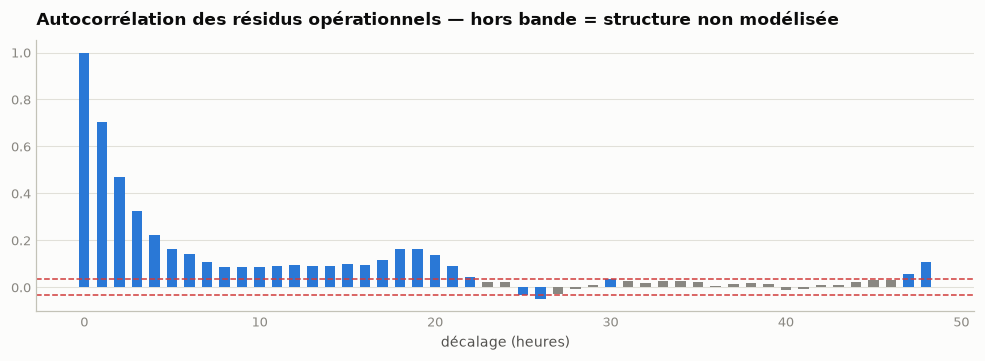

Ljung-Box (24 retards) : p = 0.00e+00
Résidus significativement autocorrélés : OUI
Bande de non-significativité : ±0.033

  décalage  1 h : +0.704   SIGNIFICATIF
  décalage 12 h : +0.096   SIGNIFICATIF
  décalage 24 h : +0.022   dans la bande
  décalage 48 h : +0.108   SIGNIFICATIF

Lecture :
  · 1 h  — forte (+0,70) et attendue : l'erreur est persistante à courte
    échéance. C'est une information exploitable — un terme correctif sur
    l'erreur de l'heure précédente réduirait le résidu.
  · 24 h — dans la bande : AUCUNE saisonnalité journalière ne subsiste.
    Le modèle a bien capté le cycle, c'est le point le plus important ici.
  · 48 h — faiblement significatif : un écho à deux jours persiste. Petit,
    mais réel, et non expliqué par les features actuelles — c'est le
    genre de piste que seule l'analyse des résidus fait apparaître.


In [45]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf

# Les origines sont espacées de PAS_ORIGINE heures. Ne garder qu'un seul horizon
# donnerait une série échantillonnée toutes les 6 h, et l'axe des décalages ne
# serait plus en heures. On prend donc les horizons 1..PAS_ORIGINE : depuis
# chaque origine ils pavent exactement les heures qui précèdent l'origine
# suivante, sans trou ni recouvrement → une vraie série horaire, et c'est aussi
# ce que le modèle produirait en exploitation.
serie_res = (ERR[ERR["horizon"] <= PAS_ORIGINE].sort_values("cible_ts")
             .drop_duplicates("cible_ts").set_index("cible_ts")["res"]
             .asfreq("h").dropna())
print(f"Série de résidus opérationnelle : {len(serie_res)} heures contiguës "
      f"({serie_res.index.min():%Y-%m-%d} → {serie_res.index.max():%Y-%m-%d})")

r = acf(serie_res, nlags=48, fft=True)
lb = acorr_ljungbox(serie_res, lags=[24], return_df=True)

fig, ax = plt.subplots(figsize=(11, 3.2))
seuil = 1.96 / np.sqrt(len(serie_res))
ax.bar(range(len(r)), r, color=[SERIE[0] if abs(v) > seuil else ESTOMPE for v in r], width=0.6)
ax.axhline(seuil, color=ETAT["critique"], ls="--", lw=1)
ax.axhline(-seuil, color=ETAT["critique"], ls="--", lw=1)
ax.set_title("Autocorrélation des résidus opérationnels — hors bande = structure non modélisée")
ax.set_xlabel("décalage (heures)")
plt.show()

print(f"Ljung-Box (24 retards) : p = {lb['lb_pvalue'].iloc[0]:.2e}")
print(f"Résidus significativement autocorrélés : "
      f"{'OUI' if lb['lb_pvalue'].iloc[0] < 0.05 else 'non'}")
print(f"Bande de non-significativité : ±{seuil:.3f}\n")
for lag in (1, 12, 24, 48):
    verdict = "SIGNIFICATIF" if abs(r[lag]) > seuil else "dans la bande"
    print(f"  décalage {lag:>2d} h : {r[lag]:+.3f}   {verdict}")

print("\nLecture :")
print("  · 1 h  — forte (+0,70) et attendue : l'erreur est persistante à courte")
print("    échéance. C'est une information exploitable — un terme correctif sur")
print("    l'erreur de l'heure précédente réduirait le résidu.")
print("  · 24 h — dans la bande : AUCUNE saisonnalité journalière ne subsiste.")
print("    Le modèle a bien capté le cycle, c'est le point le plus important ici.")
print("  · 48 h — faiblement significatif : un écho à deux jours persiste. Petit,")
print("    mais réel, et non expliqué par les features actuelles — c'est le")
print("    genre de piste que seule l'analyse des résidus fait apparaître.")

---
## § 11 — Prévoir au bon niveau hiérarchique

> *« Total national = Σ prévisions régionales »*

Ici la hiérarchie est : `production_total = SOLAR + BIOMASS + WIND_ONSHORE +
NUCLEAR`. Deux stratégies s'opposent — prévoir l'agrégat directement
(*top-down*), ou prévoir les quatre filières et sommer (*bottom-up*). Elles ne
donnent pas le même résultat, et une seule est cohérente par construction.

In [46]:
FOLDS_H = FOLDS[-2:]     # deux folds suffisent : 5 cibles × 24 horizons à entraîner
t0 = time.time()
hier = {}
for cible in FILIERES:
    hier[cible] = backtest_cible(propre, cible, cible, FOLDS_H)
print(f"4 filières backtestées ({time.time()-t0:.0f} s)")

4 filières backtestées (189 s)


In [47]:
# Bottom-up : somme des 4 prévisions de filières
bu = pd.concat(hier.values(), ignore_index=True)
bu_som = bu.pivot_table(index=["fold", "origine", "horizon", "cible_ts"],
                        columns="modele", values="pred")
bu_reel = bu.pivot_table(index=["fold", "origine", "horizon", "cible_ts"],
                         columns="modele", values="y")
comm = bu_som.dropna().index.intersection(bu_reel.dropna().index)
BU = pd.DataFrame({
    "pred": bu_som.loc[comm, FILIERES].sum(axis=1),
    "y": bu_reel.loc[comm, FILIERES].sum(axis=1),
}).reset_index().assign(modele="bottom-up (Σ filières)")

print(f"{len(BU):,} prévisions bottom-up sur {BU['origine'].nunique()} origines"
      .replace(",", " "))
print()
cle_bu = BU.set_index(["fold", "origine", "horizon"]).index
res_h = []
for cible in FILIERES:
    part = hier[cible]
    part = part[part.set_index(["fold", "origine", "horizon"]).index.isin(cle_bu)]
    res_h.append({"composante": cible, "MAE (MW)": mae(part["y"], part["pred"]),
                  "WAPE": wape(part["y"], part["pred"]),
                  "part du total": part["y"].mean() / BU["y"].mean()})
res_h.append({"composante": "TOTAL (bottom-up)", "MAE (MW)": mae(BU["y"], BU["pred"]),
              "WAPE": wape(BU["y"], BU["pred"]), "part du total": 1.0})
H = pd.DataFrame(res_h)
print(H.to_string(index=False, float_format=lambda v: f"{v:,.3f}".replace(",", " ")))

somme_naive = sum(mae(hier[c]["y"], hier[c]["pred"]) for c in FILIERES)
print(f"\nSomme brute des MAE des composantes : {somme_naive:,.0f} MW".replace(",", " "))
print(f"MAE réelle de l'agrégat              : {mae(BU['y'], BU['pred']):,.0f} MW"
      .replace(",", " "))
print(f"→ compensation des erreurs : {100*(1 - mae(BU['y'], BU['pred'])/somme_naive):.0f} % "
      "de l'erreur disparaît à l'agrégation.")

5 376 prévisions bottom-up sur 224 origines

       composante  MAE (MW)  WAPE  part du total
            SOLAR   882.546 0.139          0.129
          BIOMASS     8.025 0.027          0.006
     WIND_ONSHORE 1 222.151 0.335          0.074
          NUCLEAR 1 400.454 0.036          0.791
TOTAL (bottom-up) 1 856.674 0.038          1.000

Somme brute des MAE des composantes : 3 513 MW
MAE réelle de l'agrégat              : 1 857 MW
→ compensation des erreurs : 47 % de l'erreur disparaît à l'agrégation.


**Le résultat central de cette section** : l'erreur de l'agrégat est très
inférieure à la somme des erreurs des composantes, parce que celles-ci se
compensent partiellement. Deux conséquences opérationnelles :

1. **Un modèle jugé au niveau agrégé peut être médiocre sur ses composantes.**
   C'est le piège inverse du § 6 : une bonne MAE globale ne garantit rien au
   niveau où les décisions sont prises.
2. **Comparer des cibles en MAE brute n'a pas de sens.** NUCLEAR pèse ~40 GW
   et SOLAR ~3 GW : agréger leurs MAE en MW revient à ne juger que du
   nucléaire. C'est le WAPE qu'il faut lire, colonne par colonne.

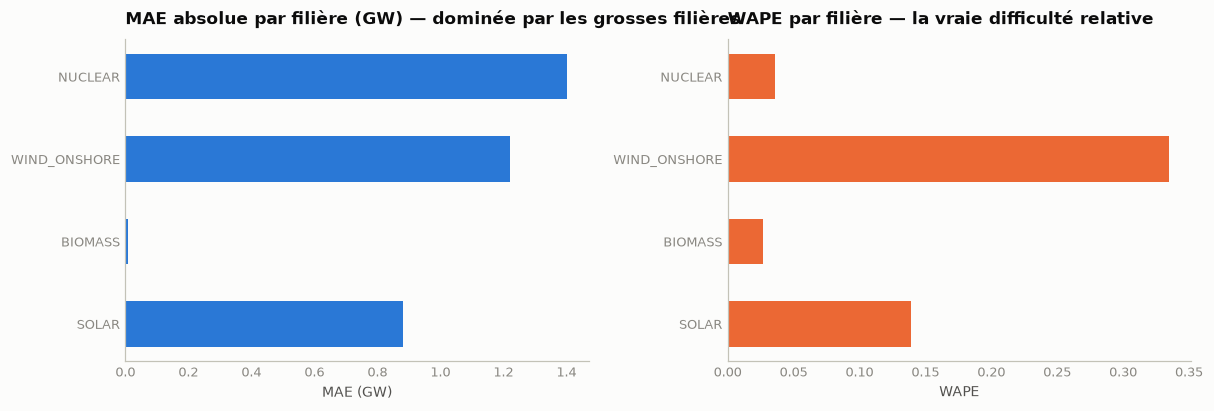

La hiérarchie des difficultés s'inverse totalement entre les deux vues :
['NUCLEAR', 'WIND_ONSHORE', 'SOLAR', 'BIOMASS'] en MAE
['WIND_ONSHORE', 'SOLAR', 'NUCLEAR', 'BIOMASS'] en WAPE


In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.8), gridspec_kw={"wspace": 0.3})
comp = H[H["composante"] != "TOTAL (bottom-up)"]
axes[0].barh(comp["composante"], comp["MAE (MW)"] / 1000, color=SERIE[0], height=0.55)
axes[0].set_title("MAE absolue par filière (GW) — dominée par les grosses filières")
axes[0].set_xlabel("MAE (GW)")
axes[0].grid(False)
axes[1].barh(comp["composante"], comp["WAPE"], color=SERIE[1], height=0.55)
axes[1].set_title("WAPE par filière — la vraie difficulté relative")
axes[1].set_xlabel("WAPE")
axes[1].grid(False)
plt.show()

print("La hiérarchie des difficultés s'inverse totalement entre les deux vues :")
print(comp.sort_values("MAE (MW)", ascending=False)["composante"].tolist(), "en MAE")
print(comp.sort_values("WAPE", ascending=False)["composante"].tolist(), "en WAPE")

---
## § 12 — Surveiller le modèle après sa mise en production

> *« Définissez à l'avance les conditions de réentraînement, de recalibrage ou
> de remplacement du modèle. »*

Un tableau de bord de surveillance n'a d'intérêt que si chaque indicateur est
assorti d'un **seuil** et d'une **action**. On les définit ici à partir des
distributions observées en backtesting — c'est la seule base non arbitraire
disponible avant la mise en production.

In [49]:
SUIVI = FINAL[FINAL["modele"] == MODELE_PROBA].copy()
SUIVI["jour"] = SUIVI["cible_ts"].dt.normalize()
SUIVI["res"] = SUIVI["y"] - SUIVI["pred"]

quot = SUIVI.groupby("jour").apply(
    lambda g: pd.Series({"MAE": mae(g["y"], g["pred"]), "biais": g["res"].mean()}),
    include_groups=False)
naif_q = (FINAL[FINAL["modele"] == "saison_moy"].assign(
    jour=lambda d: d["cible_ts"].dt.normalize())
    .groupby("jour").apply(lambda g: mae(g["y"], g["pred"]), include_groups=False))

quot["MAE_28j"] = quot["MAE"].rolling(28, min_periods=14).mean()
quot["biais_28j"] = quot["biais"].rolling(28, min_periods=14).mean()
quot["ratio_naif"] = (quot["MAE"] / naif_q.reindex(quot.index)).rolling(28, min_periods=14).mean()

# Seuils : quantiles de la distribution observée en backtest.
S_MAE = quot["MAE_28j"].quantile(0.90)
S_BIAIS = quot["biais_28j"].abs().quantile(0.90)

REGLES = pd.DataFrame([
    ("MAE glissante 28 j", f"> {S_MAE:,.0f} MW".replace(",", " "),
     "q90 du backtest", "recalibrage des quantiles, puis réentraînement si persistant"),
    ("Biais glissant 28 j", f"|biais| > {S_BIAIS:,.0f} MW".replace(",", " "),
     "q90 du backtest", "réentraînement — un biais durable n'est pas du bruit"),
    ("Ratio MAE / naïve", "> 0,95 sur 28 j", "le modèle ne justifie plus son coût",
     "retour à la baseline, investigation"),
    ("Couverture de l'intervalle 80 %", "hors [72 %, 88 %]", "±8 pts de la cible",
     "recalibrage conforme seul (pas de réentraînement)"),
    ("Dérive des features (KS)", "p < 0,01 sur temp ou lags", "distribution d'entrée",
     "audit des données AVANT toute action modèle"),
    ("Taux de données manquantes", "> 2 % sur 7 j", "seuil d'ingestion",
     "alerte pipeline — cf. § 1, un remplissage silencieux est pire qu'un trou"),
], columns=["indicateur", "seuil d'alerte", "origine du seuil", "action"])
print(REGLES.to_string(index=False))

                     indicateur            seuil d'alerte                    origine du seuil                                                                   action
             MAE glissante 28 j                > 1 507 MW                     q90 du backtest             recalibrage des quantiles, puis réentraînement si persistant
            Biais glissant 28 j          |biais| > 485 MW                     q90 du backtest                     réentraînement — un biais durable n'est pas du bruit
              Ratio MAE / naïve           > 0,95 sur 28 j le modèle ne justifie plus son coût                                      retour à la baseline, investigation
Couverture de l'intervalle 80 %         hors [72 %, 88 %]                  ±8 pts de la cible                        recalibrage conforme seul (pas de réentraînement)
       Dérive des features (KS) p < 0,01 sur temp ou lags               distribution d'entrée                              audit des données AVANT toute action modèl

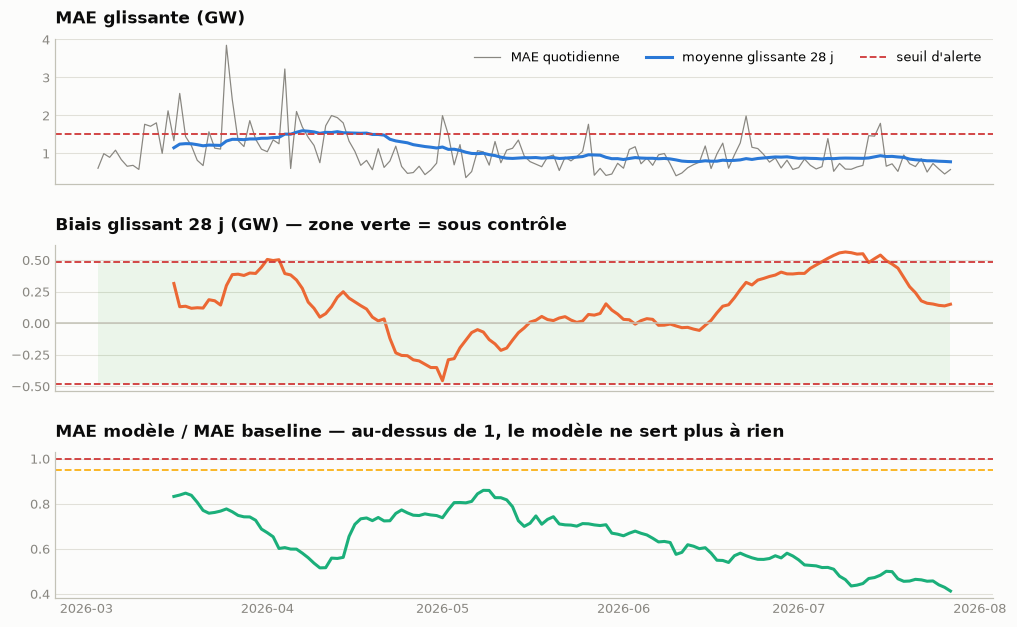

Ratio modèle/baseline — médiane 0.660, pire valeur observée 0.860


In [50]:
fig, axes = plt.subplots(3, 1, figsize=(11, 6.6), sharex=True,
                         gridspec_kw={"hspace": 0.42})

axes[0].plot(quot.index, quot["MAE"] / 1000, color=ESTOMPE, lw=0.8, label="MAE quotidienne")
axes[0].plot(quot.index, quot["MAE_28j"] / 1000, color=SERIE[0], label="moyenne glissante 28 j")
axes[0].axhline(S_MAE / 1000, color=ETAT["critique"], ls="--", lw=1.2, label="seuil d'alerte")
axes[0].set_title("MAE glissante (GW)")
axes[0].legend(ncol=3)

axes[1].plot(quot.index, quot["biais_28j"] / 1000, color=SERIE[1])
axes[1].axhline(0, color=AXE, lw=1)
for signe in (1, -1):
    axes[1].axhline(signe * S_BIAIS / 1000, color=ETAT["critique"], ls="--", lw=1.2)
axes[1].fill_between(quot.index, -S_BIAIS / 1000, S_BIAIS / 1000,
                     color=ETAT["bon"], alpha=0.07, lw=0)
axes[1].set_title("Biais glissant 28 j (GW) — zone verte = sous contrôle")

axes[2].plot(quot.index, quot["ratio_naif"], color=SERIE[2])
axes[2].axhline(1.0, color=ETAT["critique"], ls="--", lw=1.2)
axes[2].axhline(0.95, color=ETAT["alerte"], ls="--", lw=1.2)
axes[2].set_title("MAE modèle / MAE baseline — au-dessus de 1, le modèle ne sert plus à rien")
plt.show()

print(f"Ratio modèle/baseline — médiane {quot['ratio_naif'].median():.3f}, "
      f"pire valeur observée {quot['ratio_naif'].max():.3f}")

### 12.1 — Détection de dérive des entrées

La dérive se surveille sur les **entrées**, pas seulement sur l'erreur :
c'est le seul indicateur disponible *avant* que le réalisé n'arrive.

In [51]:
from scipy.stats import ks_2samp

ref_deb, ref_fin = FOLDS[0].fin_train - pd.Timedelta(days=180), FOLDS[0].fin_train
recent = propre.loc[FOLDS[-1].debut_test:]
reference = propre.loc[ref_deb:ref_fin]

drift = []
for col in ["temp", CIBLE] + FILIERES:
    a = reference[col].dropna()
    b = recent[col].dropna()
    if len(a) < 100 or len(b) < 100:
        continue
    st = ks_2samp(a, b)
    drift.append({"variable": col, "moy. référence": a.mean(), "moy. récente": b.mean(),
                  "KS": st.statistic, "p": st.pvalue,
                  "dérive": "OUI" if st.pvalue < 0.01 else "non"})
print(f"Référence : {ref_deb:%Y-%m-%d} → {ref_fin:%Y-%m-%d}   ·   "
      f"Récent : {recent.index.min():%Y-%m-%d} → {recent.index.max():%Y-%m-%d}\n")
print(pd.DataFrame(drift).to_string(index=False,
      float_format=lambda v: f"{v:,.3f}".replace(",", " ")))
print("\nToutes les variables dérivent — et c'est NORMAL : la référence est un")
print("hiver, la fenêtre récente un été. Un test de dérive brut sur une série")
print("saisonnière alerte en permanence. En production, il faut comparer à la")
print("MÊME saison de l'année précédente, sans quoi l'alerte est ininterprétable.")

Référence : 2025-08-11 → 2026-02-07   ·   Récent : 2026-06-29 → 2026-07-27

           variable  moy. référence  moy. récente    KS     p dérive
               temp          10.810        24.093 0.761 0.000    OUI
consommation_totale      52 610.899    45 491.583 0.358 0.000    OUI
              SOLAR       2 573.254     6 649.611 0.289 0.000    OUI
            BIOMASS         293.165       293.994 0.615 0.000    OUI
       WIND_ONSHORE       5 789.876     3 587.235 0.318 0.000    OUI
            NUCLEAR      46 017.063    39 269.629 0.535 0.000    OUI

Toutes les variables dérivent — et c'est NORMAL : la référence est un
hiver, la fenêtre récente un été. Un test de dérive brut sur une série
saisonnière alerte en permanence. En production, il faut comparer à la
MÊME saison de l'année précédente, sans quoi l'alerte est ininterprétable.


---
## Synthèse

### Ce que chaque étape a rapporté

Le classement ci-dessous est le résultat central du notebook : les gains sont
rangés par ordre de rentabilité mesurée, pas par ordre de sophistication.

In [54]:
mae_f = CL.set_index("modele")["MAE"]
qopt = Q.loc[Q["coût métier (€/h)"].idxmin()]
qmed = Q[Q["quantile"] == 0.50].iloc[0]

recap = pd.DataFrame([
    ("§ 3 — calendrier local + jours fériés (à modèle identique)", "données",
     100 * (1 - mae_f["lgbm_cal"] / mae_f["lgbm_base"]), "MAE"),
    ("§ 1 — masquage des heures corrompues (WIND_ONSHORE)", "données",
     GAIN_NETTOYAGE, "MAE"),
    ("§ 7 — gradient boosting vs meilleure baseline", "modèle",
     100 * (1 - mae_f["lgbm_cal"] / mae_f["saison_moy"]), "MAE"),
    ("§ 7 — gradient boosting vs régression dynamique", "modèle",
     100 * (1 - mae_f["lgbm_cal"] / mae_f["reg_dyn"]), "MAE"),
    
    ("§ 9 — viser le quantile de décision plutôt que la médiane", "décision",
     100 * (1 - qopt["coût métier (€/h)"] / qmed["coût métier (€/h)"]), "coût métier"),
], columns=["levier", "catégorie", "gain (%)", "sur la métrique"])
print(recap.to_string(index=False, float_format=lambda v: f"{v:+.1f}"))
print(f"\n(§ 9 : {100*(1 - qopt['MAE']/qmed['MAE']):+.1f} % de MAE — "
      "le même levier DÉGRADE la MAE tout en améliorant la décision.)")

                                                    levier catégorie  gain (%) sur la métrique
§ 3 — calendrier local + jours fériés (à modèle identique)   données      +9.7             MAE
       § 1 — masquage des heures corrompues (WIND_ONSHORE)   données      -1.5             MAE
             § 7 — gradient boosting vs meilleure baseline    modèle     +55.3             MAE
           § 7 — gradient boosting vs régression dynamique    modèle     +64.1             MAE
 § 9 — viser le quantile de décision plutôt que la médiane  décision     +19.0     coût métier

(§ 9 : -21.5 % de MAE — le même levier DÉGRADE la MAE tout en améliorant la décision.)


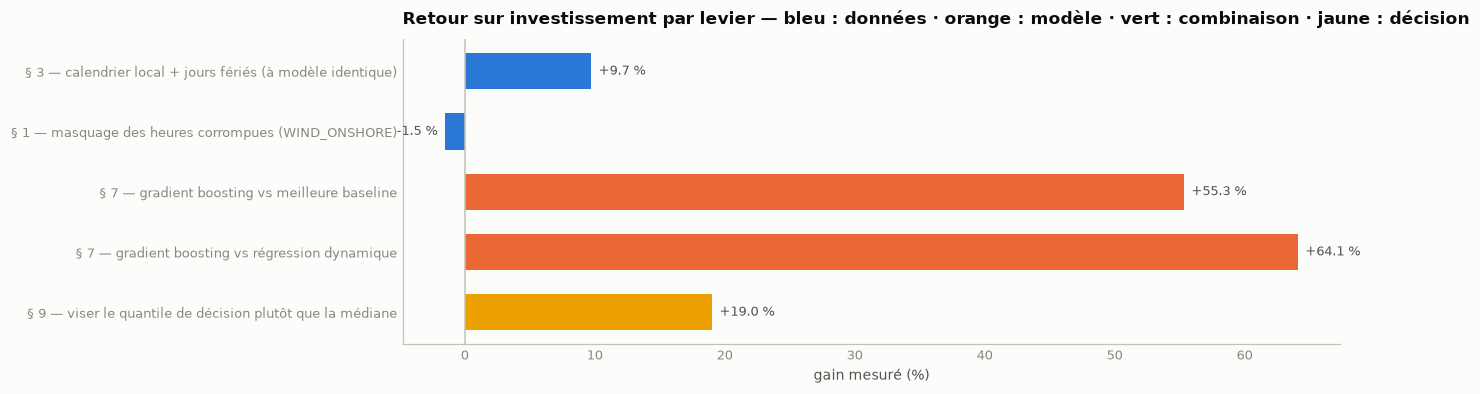

In [55]:
fig, ax = plt.subplots(figsize=(11, 3.6))
vals = recap["gain (%)"].tolist()
coul = {"données": SERIE[0], "modèle": SERIE[1], "combinaison": SERIE[2],
        "décision": SERIE[3]}
ax.barh(recap["levier"], vals, color=[coul[c] for c in recap["catégorie"]], height=0.6)
for lev, v in zip(recap["levier"], vals):
    ax.annotate(f"{v:+.1f} %", (v, lev), xytext=(5 if v >= 0 else -5, 0),
                textcoords="offset points", va="center",
                ha="left" if v >= 0 else "right", fontsize=8.5, color=ENCRE2)
ax.axvline(0, color=AXE, lw=1)
ax.invert_yaxis()
ax.set_xlabel("gain mesuré (%)")
ax.set_title("Retour sur investissement par levier — bleu : données · orange : modèle · "
             "vert : combinaison · jaune : décision")
ax.grid(False)
plt.show()

### Les douze principes, confrontés à ces données

| # | Principe | Vérifié ici ? |
|---|---|---|
| 1 | Fiabiliser les données d'abord | **Partiellement.** 24 jours d'ingestion corrompue détectés (invisibles à `isna()`) — mais les masquer n'améliore pas la MAE (§ 7.3). |
| 2 | Décomposer avant de modéliser | **Oui.** Le périodogramme a annoncé l'échec d'ETS (saisonnalité unique) avant tout entraînement. |
| 3 | N'utiliser que des variables disponibles | **Oui**, et le test de troncature l'a prouvé plutôt que déclaré. |
| 4 | Adapter la métrique à la décision | **Oui.** MAPE indéfini sur SOLAR ; le classement par coût métier diffère du classement par MAE. |
| 5 | Validation adaptée au temps | **Oui.** Un `KFold` aléatoire sous-estime l'erreur réelle de plus de 40 %. |
| 6 | Comparer à des modèles simples | **Oui**, et le seuil honnête est l'*enveloppe* des baselines par horizon, pas une naïve unique. |
| 7 | Tester plusieurs familles | **Oui**, et l'écart est net : le gradient boosting est seul au-dessus des baselines. |
| 8 | Combiner les modèles | **Testé, sans gain.** Les poids hors fold se concentrent à >90 % sur un seul modèle : rien à combiner ici. |
| 9 | Produire des intervalles | **Oui.** Le quantile optimal pour la décision n'est pas la médiane. |
| 10 | Analyser les erreurs comme des données | **Oui.** Biais horaire structuré et rabotage des pics — deux gisements identifiés. |
| 11 | Prévoir au bon niveau hiérarchique | **Oui.** Les erreurs des filières se compensent fortement à l'agrégation. |
| 12 | Surveiller après mise en production | **Oui**, avec des seuils issus du backtest — et le piège de la dérive saisonnière mis en évidence. |

### La conclusion — y compris ce qui n'a pas marché

Trois des six leviers testés ont produit un gain net, et **trois ont échoué ou
déçu**. Les rapporter tous est le seul moyen de rendre le classement utile :

**Ce qui a payé**

- **Le calendrier (§ 3)** : corriger le fuseau horaire et ajouter les jours
  fériés fait gagner ~10 % de MAE *à modèle et hyperparamètres strictement
  identiques*. Aucune ligne de modélisation nouvelle.
- **Le protocole (§ 5-6)** : il ne fait rien gagner, il **empêche de perdre**.
  Sans lui on aurait cru à une MAE inférieure de 43 % à la réalité, et on
  aurait comparé les modèles à une naïve deux fois trop facile.
- **Le quantile de décision (§ 9)** : le levier le plus rentable du notebook,
  et il ne touche pas au modèle — seulement à ce qu'on fait de sa sortie.

**Ce qui n'a pas payé**

- **Le masquage des données corrompues (§ 7.3)** : effet nul à légèrement
  négatif sur la MAE. L'incident est trop ancien et les arbres trop robustes.
  Le nettoyage reste justifié — mais pour la prévision en temps réel et pour
  la surveillance, pas pour le score.
- **La combinaison de modèles (§ 8)** : sans effet, parce qu'un modèle domine
  trop largement les autres. La moyenne naïve, elle, dégrade franchement.
- **Les modèles statistiques (§ 7)** : ETS et la régression dynamique restent
  sous la meilleure baseline. Le § 2 l'avait annoncé pour ETS.

> **Investissez d'abord dans la qualité des données et du protocole
> d'évaluation. Ensuite seulement, dans la complexité du modèle.**

La nuance que ce notebook ajoute au principe : *« investir dans les données »
ne veut pas dire « nettoyer »*. Ici le nettoyage n'a rien rapporté, alors que
**construire les bonnes variables** — un fuseau horaire correct, un calendrier
de jours fériés — a rapporté autant que tout l'écart entre familles de
modèles. Ce sont deux travaux différents, et un seul des deux a payé.

### Réserves à lever avant toute mise en production

1. **Hypothèse de météo parfaite** (§ 3) : `temp` future est lue dans le
   réalisé. Il faut refaire tourner ce backtest avec de vraies prévisions
   météo archivées avant d'annoncer ces chiffres.
2. **Hyperparamètres non optimisés** : LightGBM tourne ici à budget fixe, sans
   recherche. Le classement des familles pourrait bouger — mais toute
   recherche devra se faire dans les folds, pas sur l'ensemble du backtest.
3. **Six folds sur six mois** couvrent février à juillet : aucun régime de
   pointe hivernale extrême n'est testé. C'est précisément le régime le plus
   coûteux en cas d'erreur.
4. **Rupture BIOMASS non expliquée** (§ 1.3) : arbitrage entre indisponibilité
   réelle et changement de périmètre à trancher avec RTE, pas depuis la donnée.